#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

#Metabolite annotation

In [3]:
metabolite_names = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_tissue_name_map.csv')
metabolite_names = metabolite_names.fillna('No_id')
metabolite_names

,Query,Match,HMDB,PubChem,ChEBI,KEGG,METLIN,SMILES,Comment
0,"1,5-anhydroglucitol (1,5-AG)",No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
1,1-arachidonoyl-GPC (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
2,1-arachidonoyl-GPE (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
3,1-arachidonoyl-GPI (20:4),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
4,1-linoleoylglycerol (18:2),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
...,...,...,...,...,...,...,...,...,...
213,xanthosine,Xanthosine,HMDB0000299,64959.0,18107.0,C01762,3408.0,OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=NC2=C1N=C(...,1
214,3-phosphoglycerate,3-Phosphoglyceric acid,HMDB0000807,724.0,17050.0,C00597,150.0,OC(COP(O)(O)=O)C(O)=O,1
215,dehydroascorbate,Dehydroascorbic acid,HMDB0001264,440667.0,27956.0,C05422,342.0,[H][C@@]1(OC(=O)C(=O)C1=O)[C@@H](O)CO,1
216,pyruvate,Pyruvic acid,HMDB0000243,1060.0,32816.0,C00022,117.0,CC(=O)C(O)=O,1


In [4]:
metabolite_name_dict = dict(zip(metabolite_names['Query'], metabolite_names['HMDB']))
metabolite_name_dict

{'1,5-anhydroglucitol (1,5-AG)': 'No_id',
 '1-arachidonoyl-GPC (20:4n6)': 'No_id',
 '1-arachidonoyl-GPE (20:4n6)': 'No_id',
 '1-arachidonoyl-GPI (20:4)': 'No_id',
 '1-linoleoylglycerol (18:2)': 'No_id',
 '1-linoleoyl-GPC (18:2)': 'HMDB0010386',
 '1-oleoylglycerol (1-monoolein)': 'HMDB0011567',
 '1-oleoyl-GPE (18:1)': 'No_id',
 '1-palmitoleoyl-GPC (16:1)': 'No_id',
 '1-palmitoylglycerol (1-monopalmitin)': 'No_id',
 '1-palmitoyl-GPC (16:0)': 'HMDB0010382',
 '1-palmitoyl-GPE (16:0)': 'HMDB0011503',
 '1-palmitoyl-GPI (16:0)': 'No_id',
 '1-(1-enyl-palmitoyl)-GPE (P-16:0)': 'No_id',
 '1-stearoyl-GPC (18:0)': 'No_id',
 '1-stearoyl-GPI (18:0)': 'No_id',
 '10-heptadecenoate (17:1n7)': 'HMDB0060038',
 '10-nonadecenoate (19:1n9)': 'HMDB0013622',
 '13-HODE + 9-HODE': 'No_id',
 'methyl palmitate (15 or 2)': 'HMDB0061709',
 "2'-deoxyguanosine": 'HMDB0000085',
 "2'-deoxyinosine": 'HMDB0000071',
 '2-aminoadipate': 'HMDB0000510',
 '2-hydroxyglutarate': 'HMDB0059655',
 '2-hydroxypalmitate': 'HMDB0031057

In [5]:
#In the prediction metabolite annotation two metabolites are matched to the same HMDB ID so just remove those
#Drop the 'HMDB0000759' from both real and prediction data

from collections import Counter

unique_columns = [i for i in metabolite_name_dict.values()]

counts = Counter(unique_columns)

duplicates = [item for item, count in counts.items() if count > 1]
duplicates

['No_id', 'HMDB0000759']

#LCMS data

In [6]:
lcms = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_data_processed/metabolites_fudan_hmdb.csv', index_col = 0)
lcms = lcms.drop('HMDB0000759', axis = 'columns')
lcms.head(3)

,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,HMDB0000696,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC002,21.291669,17.379201,19.533546,14.752381,17.281514,13.438272,15.498725,15.460840,17.108708,18.389594,...,15.014544,16.147682,14.095067,19.686661,11.607330,15.498725,15.209910,17.454026,14.036174,12.963980
FUSCCTNBC049,22.449926,16.339084,19.881713,14.788514,19.866545,13.159556,15.739253,15.798674,14.671762,18.054933,...,14.693705,13.076816,13.666224,20.624987,13.371777,16.040461,14.952195,14.508042,13.938477,12.983706
FUSCCTNBC053,23.202486,17.216357,19.696190,14.371777,17.997979,14.010178,14.970286,16.732366,14.027560,18.714715,...,14.747144,12.264443,14.609640,21.766542,11.264443,16.055367,14.778283,11.903129,14.103288,12.593391


#RNA sequencing data

In [7]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_data_processed/fudan_tpm_ensembl_id.csv', index_col = 0)
rna.index.name = None
rna

,ENSG00000034510,ENSG00000156508,ENSG00000227097,ENSG00000184009,ENSG00000140988,ENSG00000096384,ENSG00000161016,ENSG00000112306,ENSG00000229117,ENSG00000087086,...,ENSG00000223400,ENSG00000160180,ENSG00000160182,ENSG00000214326,ENSG00000229880,ENSG00000228930,ENSG00000275167,ENSG00000226115,ENSG00000233767,ENSG00000274847
FUSCCTNBC182,2447.155381,956.960040,185.220607,449.733950,398.575769,331.961043,485.891503,1032.302152,410.780763,1997.442072,...,0.0,0.629655,0.589982,0.0,0.0,0.0,0.0,0.353989,0.000000,0.453832
FUSCCTNBC203,3615.273039,1264.796635,212.927405,613.107390,410.668291,491.207544,371.948287,961.535813,440.800609,1747.999510,...,0.0,1.102217,0.000000,0.0,0.0,0.0,0.0,0.495729,0.000000,0.127110
FUSCCTNBC202,3142.598252,1128.969744,23.449189,488.009336,1362.397880,1019.435393,724.029280,924.140245,1062.730790,1050.809965,...,0.0,0.640911,2.802464,0.0,0.0,0.0,0.0,0.000000,0.000000,0.615926
FUSCCTNBC252,3077.853838,1747.266355,46.534260,1970.791018,1017.886626,1072.102967,1878.768767,3677.076850,1007.322009,836.004482,...,0.0,0.000000,0.651219,0.0,0.0,0.0,0.0,1.172194,0.000000,0.500938
FUSCCTNBC187,3355.012056,1385.507343,140.305852,639.268155,714.213497,488.831249,554.244668,1772.914800,524.592853,3068.234283,...,0.0,2.752266,0.573078,0.0,0.0,0.0,0.0,1.031540,0.000000,0.352663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FUSCCTNBC478,2089.976932,1044.355445,153.284510,546.111531,507.092984,284.833353,392.680622,720.050386,640.417632,2146.178083,...,0.0,1.091030,0.000000,0.0,0.0,0.0,0.0,0.000000,1.226743,1.258198
FUSCCTNBC475,1880.619141,1095.808585,40.975269,996.981628,572.619756,511.969661,359.219520,899.688318,513.686189,781.535580,...,0.0,11.632138,5.069404,0.0,0.0,0.0,0.0,0.608328,0.000000,0.311963
FUSCCTNBC476,5419.466045,708.611839,236.248170,603.593763,595.921308,513.001821,373.973293,527.592540,655.816273,631.554989,...,0.0,81.840094,67.537764,0.0,0.0,0.0,0.0,0.000000,0.000000,0.865869
FUSCCTNBC479,2310.399136,1110.229721,14.343541,607.186315,654.144769,526.013277,623.449097,739.444346,808.675394,949.856546,...,0.0,659.927355,1272.202144,0.0,0.0,0.0,0.0,0.000000,0.000000,0.502338


In [8]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000034510,ENSG00000156508,ENSG00000227097,ENSG00000184009,ENSG00000140988,ENSG00000096384,ENSG00000161016,ENSG00000112306,ENSG00000229117,ENSG00000087086,...,ENSG00000223400,ENSG00000160180,ENSG00000160182,ENSG00000214326,ENSG00000229880,ENSG00000228930,ENSG00000275167,ENSG00000226115,ENSG00000233767,ENSG00000274847
FUSCCTNBC182,11.257479,9.903822,7.540869,8.816132,8.642325,8.379210,8.927457,10.013046,8.685733,10.964660,...,0.0,0.704567,0.669010,0.0,0.0,0.0,0.0,0.437216,0.0,0.539861
FUSCCTNBC203,11.820288,10.305830,7.740978,9.262347,8.685339,8.943123,8.542832,9.910696,8.787252,10.772314,...,0.0,1.071912,0.000000,0.0,0.0,0.0,0.0,0.580849,0.0,0.172628
FUSCCTNBC202,11.618201,10.142068,4.611715,8.933718,10.412991,9.994969,9.501895,9.853528,10.054917,10.038658,...,0.0,0.714497,1.926935,0.0,0.0,0.0,0.0,0.000000,0.0,0.692361


In [9]:
common_index = list(set(rna.index).intersection(set(lcms.index)))
rna = rna.loc[common_index]
lcms = lcms.loc[common_index]
print(rna.shape)
print(lcms.shape)

(230, 32061)
(230, 101)


#Metabolite prediction function

In [10]:
def nn_predict(model, data, input_features, output_features):
  data = data.copy()
  data = data.reindex(input_features, axis = 'columns')
  data = data.fillna(0)

  predictions = model.predict(data)
  predictions = pd.DataFrame(predictions, index = data.index, columns = output_features)
  predictions = predictions.rename(columns = metabolite_name_dict)
  common_metabolites = list(set(predictions.columns.to_list()).intersection(set(lcms.columns.to_list())))
  predictions = predictions[common_metabolites]

  return predictions

#MLP

In [11]:
mlp_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/MLP_model.keras')
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │       285,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 218)            │        22,018 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 922,556 (3.52 MB)

 Trainable params: 307,518 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 615,038 (2.35 MB)

In [12]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/MLP_model_features_input.pkl', 'rb') as f:
  mlp_model_input_features = pickle.load(f)

print(mlp_model_input_features)

['ENSG00000198712', 'ENSG00000198804', 'ENSG00000198938', 'ENSG00000198899', 'ENSG00000198886', 'ENSG00000212907', 'ENSG00000198763', 'ENSG00000198840', 'ENSG00000156508', 'ENSG00000198888', 'ENSG00000198727', 'ENSG00000198695', 'ENSG00000198786', 'ENSG00000167658', 'ENSG00000111640', 'ENSG00000167996', 'ENSG00000074800', 'ENSG00000110955', 'ENSG00000084207', 'ENSG00000196262', 'ENSG00000111669', 'ENSG00000176340', 'ENSG00000005022', 'ENSG00000169100', 'ENSG00000136810', 'ENSG00000168653', 'ENSG00000233276', 'ENSG00000067225', 'ENSG00000117450', 'ENSG00000103257', 'ENSG00000228253', 'ENSG00000126432', 'ENSG00000178952', 'ENSG00000173660', 'ENSG00000169710', 'ENSG00000099194', 'ENSG00000179091', 'ENSG00000171314', 'ENSG00000197746', 'ENSG00000134333', 'ENSG00000167468', 'ENSG00000185624', 'ENSG00000117592', 'ENSG00000110958', 'ENSG00000178035', 'ENSG00000099795', 'ENSG00000089597', 'ENSG00000115758', 'ENSG00000135821', 'ENSG00000126267', 'ENSG00000100994', 'ENSG00000102144', 'ENSG000001

In [13]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/MLP_model_features_output.pkl', 'rb') as f:
  mlp_model_output_features = pickle.load(f)

print(mlp_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

In [14]:
mlp_model_pred = nn_predict(model = mlp_model,
                            data = rna,
                            input_features = mlp_model_input_features,
                            output_features = mlp_model_output_features)
mlp_model_pred.head(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,HMDB0028691,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,-0.381698,-0.638154,0.296538,-0.240894,-0.310035,-0.277015,-0.223582,0.446501,-0.664239,0.333135,...,0.050100,0.125424,-0.390084,-0.621574,0.126230,0.069957,0.193139,0.182019,-0.442293,-0.575862
FUSCCTNBC404,-0.418748,-0.634509,0.275494,-0.272511,-0.247199,-0.377482,-0.345156,0.571619,-0.545053,0.180144,...,0.025282,0.323750,-0.432723,-0.743052,0.102638,0.363232,0.131119,0.228406,-0.383145,-0.572646
FUSCCTNBC393,-0.370448,-0.639694,0.305377,-0.228397,-0.318873,-0.274267,-0.205024,0.424668,-0.674975,0.352717,...,0.051839,0.094079,-0.381851,-0.605626,0.129630,0.036061,0.194111,0.178251,-0.450886,-0.574949


#Transfer model metabolic genes


In [15]:
met_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_nn_model.keras')

In [16]:
met_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2854)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,923,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,754,896 (14.32 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 3,586,816 (13.68 MB)

 Optimizer params: 112,054 (437.71 KB)

In [17]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_nn_model_features_input.pkl', 'rb') as f:
  met_model_input_features = pickle.load(f)

print(met_model_input_features)

['ENSG00000198712', 'ENSG00000198804', 'ENSG00000198938', 'ENSG00000198899', 'ENSG00000198886', 'ENSG00000212907', 'ENSG00000198763', 'ENSG00000198840', 'ENSG00000156508', 'ENSG00000198888', 'ENSG00000198727', 'ENSG00000198695', 'ENSG00000198786', 'ENSG00000167658', 'ENSG00000111640', 'ENSG00000167996', 'ENSG00000074800', 'ENSG00000110955', 'ENSG00000084207', 'ENSG00000196262', 'ENSG00000111669', 'ENSG00000176340', 'ENSG00000005022', 'ENSG00000169100', 'ENSG00000136810', 'ENSG00000168653', 'ENSG00000233276', 'ENSG00000067225', 'ENSG00000117450', 'ENSG00000103257', 'ENSG00000228253', 'ENSG00000126432', 'ENSG00000178952', 'ENSG00000173660', 'ENSG00000169710', 'ENSG00000099194', 'ENSG00000179091', 'ENSG00000171314', 'ENSG00000197746', 'ENSG00000134333', 'ENSG00000167468', 'ENSG00000185624', 'ENSG00000117592', 'ENSG00000110958', 'ENSG00000178035', 'ENSG00000099795', 'ENSG00000089597', 'ENSG00000115758', 'ENSG00000135821', 'ENSG00000126267', 'ENSG00000100994', 'ENSG00000102144', 'ENSG000001

In [18]:
len(met_model_input_features)

2854

In [19]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_nn_model_features_output.pkl', 'rb') as f:
  met_model_output_features = pickle.load(f)

print(met_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

In [20]:
met_model_pred = nn_predict(model = met_model,
                            data = rna,
                            input_features = met_model_input_features,
                            output_features = met_model_output_features)
met_model_pred.head(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,HMDB0028691,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,-21.964277,10.217503,-29.446695,-32.696823,-16.542633,-16.973541,-41.402466,-76.226379,26.212818,-55.103546,...,18.976393,-2.003836,-22.625246,-6.787869,-38.606766,-83.253029,-149.984146,1.613018,59.219208,-20.162313
FUSCCTNBC404,-10.948526,32.520569,-36.276711,-23.892618,-7.834354,-22.158501,-37.088867,-89.283119,63.052113,-66.123283,...,35.070690,11.446020,-27.737196,10.405229,-40.947117,-88.491798,-173.827545,13.791787,93.415100,-3.276478
FUSCCTNBC393,-10.567409,31.413456,-31.959164,-23.918390,-8.545266,-23.299690,-34.447727,-87.985649,60.342102,-64.834526,...,33.382336,10.906580,-26.667715,9.928416,-39.664181,-84.117676,-164.324951,13.959058,89.254288,-4.955713


#Transfer model TFs

In [21]:
tf_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_tfs_nn_model.keras')

In [22]:
tf_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 682)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       699,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,530,768 (5.84 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 1,362,688 (5.20 MB)

 Optimizer params: 112,054 (437.71 KB)

In [23]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_tfs_nn_model_features_input.pkl', 'rb') as f:
  tf_model_input_features = pickle.load(f)

print(tf_model_input_features)

['ENSG00000164930', 'ENSG00000064961', 'ENSG00000074219', 'ENSG00000077150', 'ENSG00000169136', 'ENSG00000197905', 'ENSG00000124226', 'ENSG00000159184', 'ENSG00000137166', 'ENSG00000108654', 'ENSG00000168496', 'ENSG00000055130', 'ENSG00000163132', 'ENSG00000124575', 'ENSG00000165672', 'ENSG00000107447', 'ENSG00000126778', 'ENSG00000113068', 'ENSG00000112715', 'ENSG00000163558', 'ENSG00000215301', 'ENSG00000087191', 'ENSG00000135111', 'ENSG00000111206', 'ENSG00000168283', 'ENSG00000117318', 'ENSG00000213676', 'ENSG00000172534', 'ENSG00000144485', 'ENSG00000114554', 'ENSG00000115641', 'ENSG00000165030', 'ENSG00000106261', 'ENSG00000196843', 'ENSG00000196975', 'ENSG00000106483', 'ENSG00000136997', 'ENSG00000135363', 'ENSG00000103994', 'ENSG00000173253', 'ENSG00000180818', 'ENSG00000197780', 'ENSG00000204209', 'ENSG00000157933', 'ENSG00000118418', 'ENSG00000185650', 'ENSG00000164920', 'ENSG00000170608', 'ENSG00000082175', 'ENSG00000137310', 'ENSG00000129654', 'ENSG00000177700', 'ENSG000001

In [24]:
len(tf_model_input_features)

682

In [25]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_tfs_nn_model_features_output.pkl', 'rb') as f:
  tf_model_output_features = pickle.load(f)

print(tf_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

In [26]:
tf_model_pred = nn_predict(model = tf_model,
                           data = rna,
                           input_features = tf_model_input_features,
                           output_features = tf_model_output_features)
tf_model_pred.head(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,HMDB0028691,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,51.829071,18.261368,-31.064335,9.095922,71.981972,31.552460,4.684867,19.527298,66.573997,17.268335,...,37.338371,2.219231,-3.063375,55.549862,20.938702,0.202145,-48.962120,20.291077,80.824791,49.676971
FUSCCTNBC404,68.920670,28.597906,-33.270821,16.378120,91.487267,40.118790,4.097013,17.715994,88.345512,19.708502,...,49.343735,6.718495,0.786817,71.836327,22.399719,2.411797,-60.867046,28.866692,105.138954,65.529495
FUSCCTNBC393,67.381935,28.752384,-32.584080,15.980456,88.730095,39.655678,4.210826,17.514280,86.674660,19.158728,...,48.728039,6.808037,0.650208,70.302841,21.937302,2.501820,-59.643242,28.096729,102.710213,64.243187


#Transfer model combination

In [27]:
combo_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_combination_nn_model.keras')

In [28]:
combo_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3493)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,577,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,409,232 (16.82 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 4,241,152 (16.18 MB)

 Optimizer params: 112,054 (437.71 KB)

In [29]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_combination_nn_model_features_input.pkl', 'rb') as f:
  combo_model_input_features = pickle.load(f)

print(combo_model_input_features)

['ENSG00000164930', 'ENSG00000197594', 'ENSG00000124226', 'ENSG00000159184', 'ENSG00000198668', 'ENSG00000179142', 'ENSG00000007350', 'ENSG00000129744', 'ENSG00000170035', 'ENSG00000170950', 'ENSG00000167815', 'ENSG00000146151', 'ENSG00000145384', 'ENSG00000102226', 'ENSG00000109452', 'ENSG00000100121', 'ENSG00000163558', 'ENSG00000135111', 'ENSG00000110887', 'ENSG00000111206', 'ENSG00000078295', 'ENSG00000077044', 'ENSG00000172534', 'ENSG00000156795', 'ENSG00000165195', 'ENSG00000176383', 'ENSG00000170142', 'ENSG00000132330', 'ENSG00000123453', 'ENSG00000165030', 'ENSG00000124615', 'ENSG00000143207', 'ENSG00000142657', 'ENSG00000164405', 'ENSG00000099810', 'ENSG00000157326', 'ENSG00000110066', 'ENSG00000163218', 'ENSG00000109332', 'ENSG00000165475', 'ENSG00000056998', 'ENSG00000135363', 'ENSG00000277893', 'ENSG00000149313', 'ENSG00000100889', 'ENSG00000180818', 'ENSG00000012779', 'ENSG00000174233', 'ENSG00000134824', 'ENSG00000105939', 'ENSG00000124596', 'ENSG00000174165', 'ENSG000001

In [30]:
len(combo_model_input_features)

3493

In [31]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_combination_nn_model_features_output.pkl', 'rb') as f:
  combo_model_output_features = pickle.load(f)

print(combo_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

In [32]:
combo_model_pred = nn_predict(model = combo_model,
                              data = rna,
                              input_features = combo_model_input_features,
                              output_features = combo_model_output_features)
combo_model_pred.head(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,HMDB0028691,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,18.453428,92.458481,65.840866,-19.117300,50.408699,-59.903706,9.417955,-38.059944,79.386711,-42.610577,...,-0.294437,-26.120506,14.532648,68.489136,-15.194476,71.706856,-3.872625,23.381006,73.626411,40.393730
FUSCCTNBC404,30.962437,131.551682,91.204575,-15.911713,74.757301,-70.229042,19.988916,-56.937103,112.052818,-59.333691,...,7.334784,-22.972719,22.715878,92.829575,-15.131509,99.732231,10.481916,37.377373,106.871368,54.052639
FUSCCTNBC393,27.609634,118.578682,83.420197,-17.565800,67.160805,-64.880501,16.066233,-51.358521,101.217979,-55.953697,...,5.589924,-22.130301,20.431133,83.006409,-15.851851,90.941284,5.060831,32.917984,95.002533,47.576954


#Transfer model top variance features

In [33]:
var_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_unbiased_features_nn_model.keras')

In [34]:
var_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3030)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,103,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_output_dense (Dense)        │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,935,120 (15.01 MB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 3,767,040 (14.37 MB)

 Optimizer params: 112,054 (437.71 KB)

In [35]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_unbiased_features_nn_model_features_input.pkl', 'rb') as f:
  var_model_input_features = pickle.load(f)

print(var_model_input_features)

['ENSG00000000005', 'ENSG00000000419', 'ENSG00000000971', 'ENSG00000001617', 'ENSG00000002549', 'ENSG00000002586', 'ENSG00000002726', 'ENSG00000002834', 'ENSG00000002933', 'ENSG00000003989', 'ENSG00000004059', 'ENSG00000004142', 'ENSG00000004478', 'ENSG00000004776', 'ENSG00000004779', 'ENSG00000004799', 'ENSG00000004939', 'ENSG00000005022', 'ENSG00000005075', 'ENSG00000005421', 'ENSG00000005486', 'ENSG00000005513', 'ENSG00000005884', 'ENSG00000006016', 'ENSG00000006125', 'ENSG00000006128', 'ENSG00000006210', 'ENSG00000006327', 'ENSG00000006659', 'ENSG00000006831', 'ENSG00000007080', 'ENSG00000007255', 'ENSG00000007306', 'ENSG00000007312', 'ENSG00000007350', 'ENSG00000007933', 'ENSG00000007952', 'ENSG00000008018', 'ENSG00000008282', 'ENSG00000008283', 'ENSG00000008394', 'ENSG00000008441', 'ENSG00000008517', 'ENSG00000008988', 'ENSG00000009307', 'ENSG00000009765', 'ENSG00000010256', 'ENSG00000010278', 'ENSG00000010438', 'ENSG00000010610', 'ENSG00000011009', 'ENSG00000011028', 'ENSG000000

In [36]:
len(var_model_input_features)

3030

In [37]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/Transfer_metabolomics_unbiased_features_nn_model_features_output.pkl', 'rb') as f:
  var_model_output_features = pickle.load(f)

print(var_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

In [38]:
var_model_pred = nn_predict(model = var_model,
                            data = rna,
                            input_features = var_model_input_features,
                            output_features = var_model_output_features)
var_model_pred.head(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,HMDB0028691,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,-267.921509,-134.498886,-503.180725,-271.320984,-72.774445,307.508636,-300.140839,56.059952,-361.761353,-448.278656,...,-117.799232,-451.164642,189.690033,-108.582893,52.074059,-116.309219,-601.397339,-143.125748,-85.897423,-345.866364
FUSCCTNBC404,-267.662872,-114.750809,-554.829590,-275.634521,-76.419678,327.058563,-301.475586,54.699203,-361.713470,-486.514099,...,-104.029518,-484.596405,208.137085,-110.478065,75.989853,-110.331680,-636.396606,-135.322708,-65.641312,-355.771942
FUSCCTNBC393,-277.890137,-130.380203,-520.501526,-274.860352,-63.646118,326.028687,-309.380707,63.946625,-369.300812,-472.099121,...,-111.487526,-464.390472,205.046829,-109.525063,63.846397,-113.422531,-624.485413,-146.682480,-79.036865,-350.552826


#BulkRNABert model

In [39]:
brb_embeddings = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/BulkRNABert_data/fudan_bulkrnabert_embeddings.csv', index_col = 0)
brb_embeddings = brb_embeddings.loc[common_index]
print(brb_embeddings.shape)
brb_embeddings.head(3)

(230, 256)


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
FUSCCTNBC028,0.918237,0.356329,1.004034,-0.977051,0.510439,1.092318,0.281422,0.748191,0.316927,0.001529,...,-0.072520,0.091448,0.233908,0.183912,-0.005927,1.401588,0.344475,0.420849,-0.062680,0.612569
FUSCCTNBC404,0.955572,0.435912,0.396501,-1.358561,0.555262,1.330302,0.355786,0.662714,0.481128,-0.477889,...,-0.168837,-0.028677,-0.020231,0.160899,0.044804,1.574928,0.408560,0.422122,-0.254844,0.625151
FUSCCTNBC393,0.873358,0.380743,0.657686,-1.221726,0.512336,1.292093,0.396762,0.693710,0.443579,-0.189800,...,-0.013222,-0.068574,0.172730,0.094839,0.116070,1.483422,0.341014,0.410963,-0.128206,0.728844


In [40]:
brb_embeddings.shape

(230, 256)

In [41]:
brb_nn_model = tf.keras.models.load_model('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/bulkrnabert_regression_head.keras')

In [42]:
brb_nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,080 (656.57 KB)

 Trainable params: 56,026 (218.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 112,054 (437.71 KB)

In [43]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/bulkrnabert_regression_head_model_features_output.pkl', 'rb') as f:
  brb_nn_model_output_features = pickle.load(f)

print(brb_nn_model_output_features)

['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)', '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)', '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)', '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)', '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)', '1-palmitoyl-GPC (16:0)', '1-palmitoyl-GPE (16:0)', '1-palmitoyl-GPI (16:0)', '1-(1-enyl-palmitoyl)-GPE (P-16:0)', '1-stearoyl-GPC (18:0)', '1-stearoyl-GPI (18:0)', '10-heptadecenoate (17:1n7)', '10-nonadecenoate (19:1n9)', '13-HODE + 9-HODE', 'methyl palmitate (15 or 2)', "2'-deoxyguanosine", "2'-deoxyinosine", '2-aminoadipate', '2-hydroxyglutarate', '2-hydroxypalmitate', '2-methylbutyroylcarnitine', '2-palmitoyl-GPC (16:0)', '3-(4-hydroxyphenyl)lactate', '3-aminoisobutyrate', '3-carboxy-4-methyl-5-propyl-2-furanpropanoate (CMPF)', '3-hydroxybutyrate (BHBA)', '3-indoxyl sulfate', '3-methyl-2-oxovalerate', '3-methylhistidine', '4-acetamidophenol', '4-acetaminophen sulfate', '4-androste

In [44]:
brb_nn_model_pred = nn_predict(model = brb_nn_model,
                               data = brb_embeddings,
                               input_features = brb_embeddings.columns.to_list(),
                               output_features = brb_nn_model_output_features)
var_model_pred.head(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,HMDB0028691,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,-267.921509,-134.498886,-503.180725,-271.320984,-72.774445,307.508636,-300.140839,56.059952,-361.761353,-448.278656,...,-117.799232,-451.164642,189.690033,-108.582893,52.074059,-116.309219,-601.397339,-143.125748,-85.897423,-345.866364
FUSCCTNBC404,-267.662872,-114.750809,-554.829590,-275.634521,-76.419678,327.058563,-301.475586,54.699203,-361.713470,-486.514099,...,-104.029518,-484.596405,208.137085,-110.478065,75.989853,-110.331680,-636.396606,-135.322708,-65.641312,-355.771942
FUSCCTNBC393,-277.890137,-130.380203,-520.501526,-274.860352,-63.646118,326.028687,-309.380707,63.946625,-369.300812,-472.099121,...,-111.487526,-464.390472,205.046829,-109.525063,63.846397,-113.422531,-624.485413,-146.682480,-79.036865,-350.552826


#Model assessment

In [45]:
from scipy.stats import spearmanr

metabolites_spearman_positive_all = {}
metabolites_spearman_negative_all = {}

def plot_spearman_per_metabolite(y_pred, y_true, model_name):
    """Plots the Spearman's correlation coefficient per metabolite."""

    spearman_coeffs = []
    for i in range(y_true.shape[1]):
        coeff, _ = spearmanr(y_true.iloc[:, i], y_pred.iloc[:, i])
        spearman_coeffs.append(coeff)

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_true.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)
    metabolites_spearman_positive = spearman_df[spearman_df['Spearman Coefficient'] > 0]
    metabolites_spearman_positive_all[model_name] = list(metabolites_spearman_positive['Metabolite'])
    metabolites_spearman_negative = spearman_df[spearman_df['Spearman Coefficient'] < 0]
    metabolites_spearman_negative_all[model_name] = list(metabolites_spearman_negative['Metabolite'])


    # Plotting
    plt.figure(figsize=(10, 6))
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name} - Fudan)")
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])
    plt.xticks()
    plt.xlabel("Metabolite")
    plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Spearmans Corr per metabolite({model_name} Fudan.svg', bbox_inches = 'tight')
    plt.show()

In [46]:
def get_spearman_correlation(y_pred, y_true, model_name):

  correlation, p_value = spearmanr(y_true, y_pred)

  # Use .values.ravel() or .to_numpy().flatten()
  correlation_df = pd.DataFrame({'Actual': y_true.values.ravel(), 'Predicted': y_pred.values.ravel()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name} - Fudan)')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Spearmans Corr ({model_name} Fudan).svg', bbox_inches = 'tight')
  plt.show()

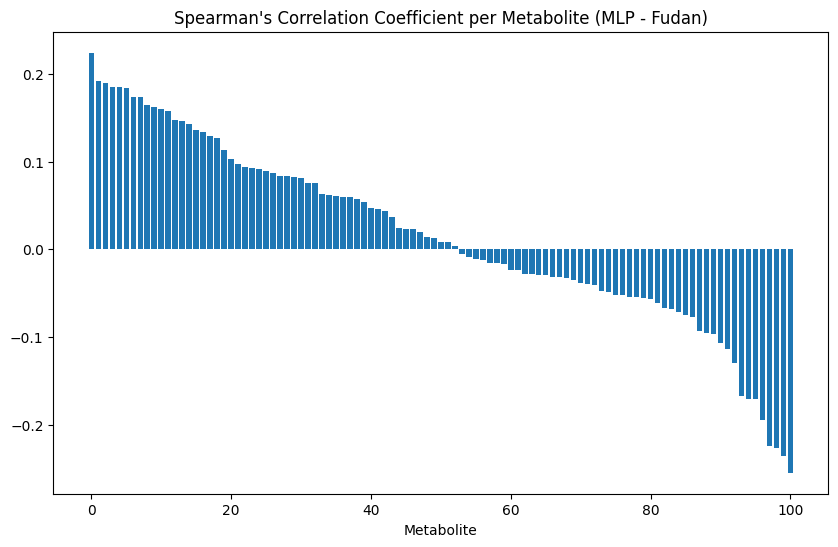

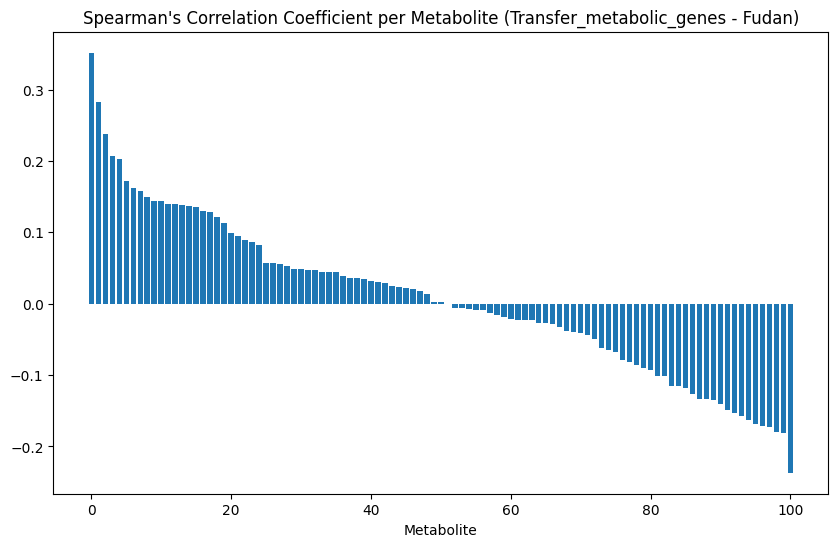

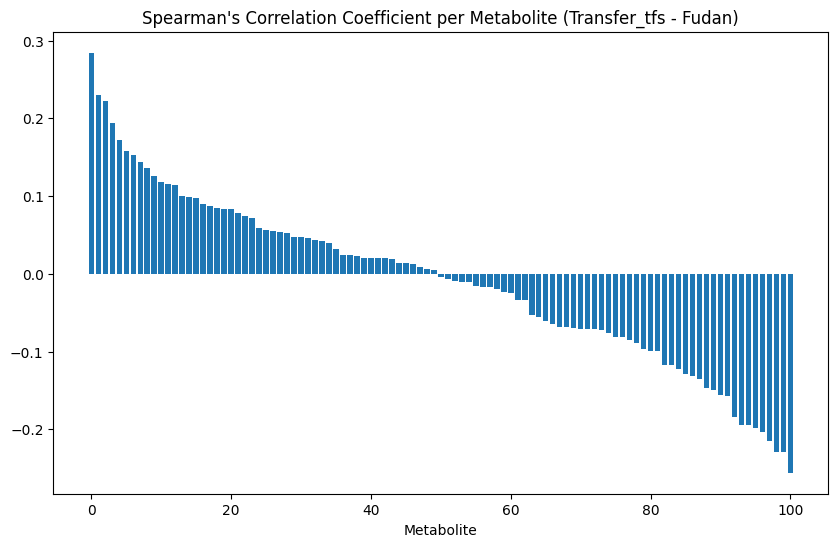

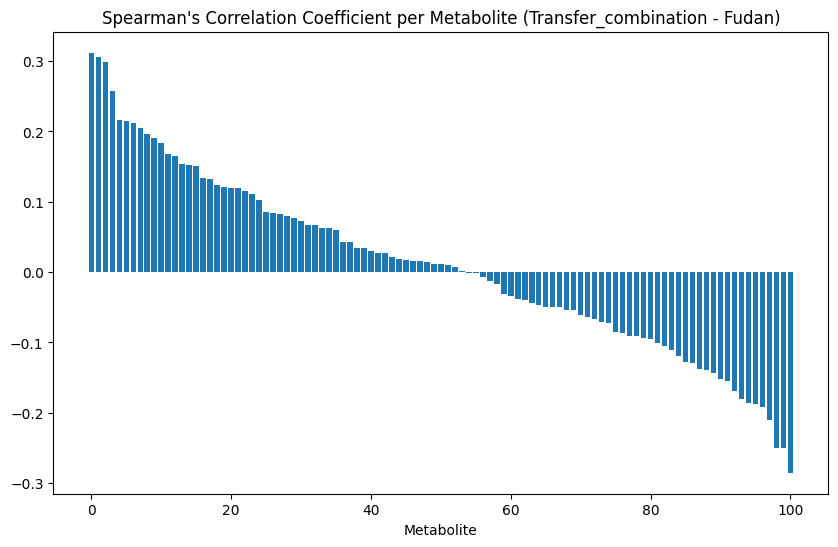

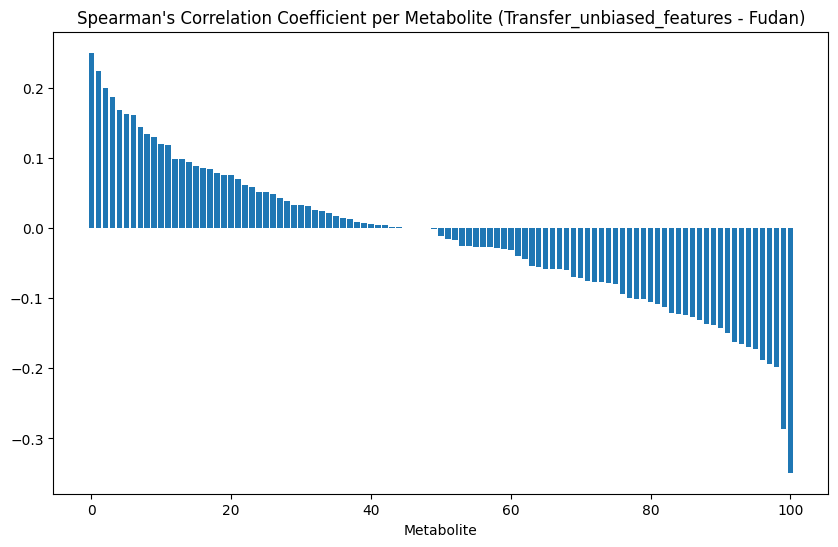

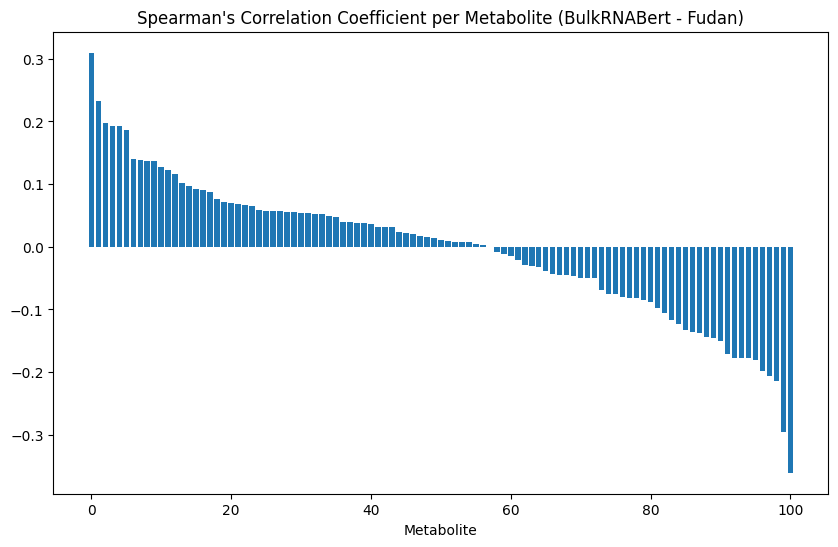

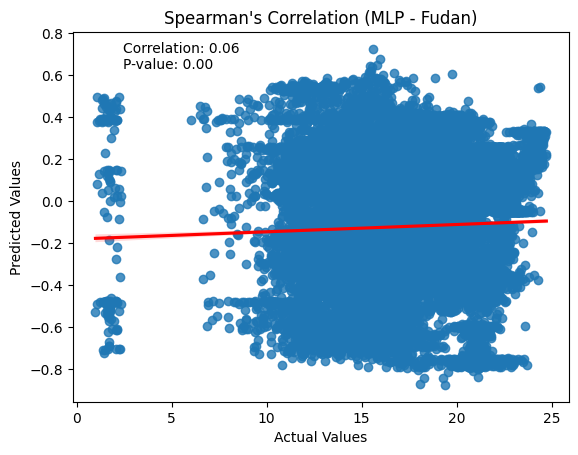

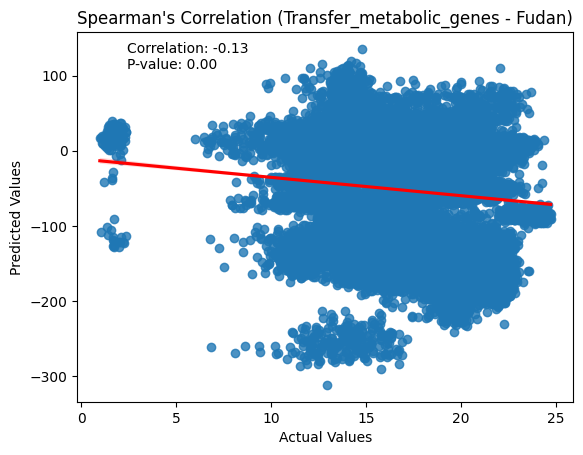

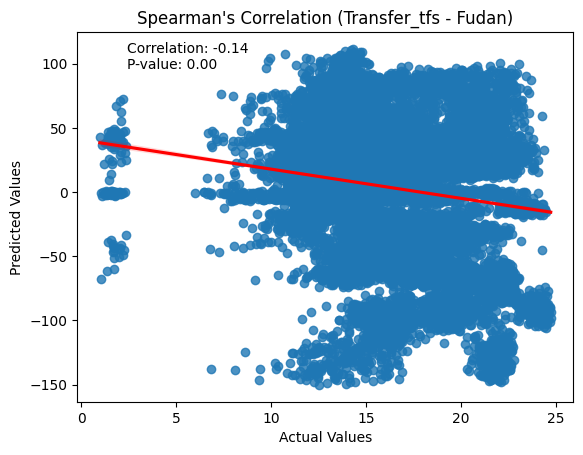

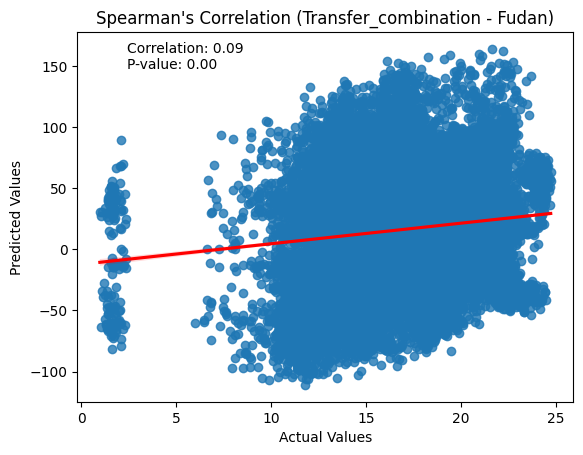

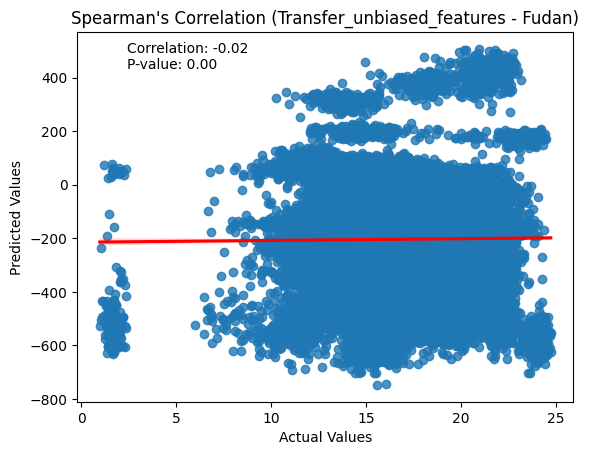

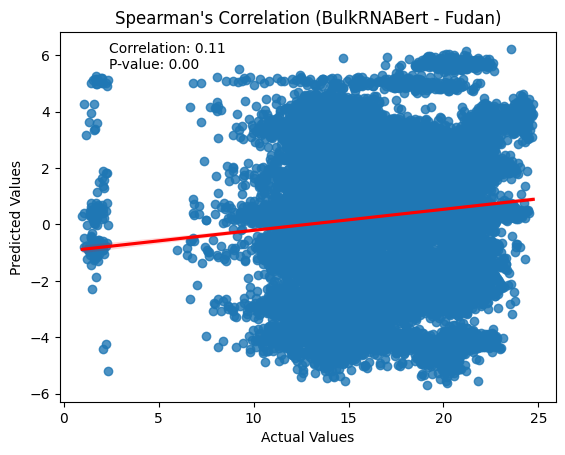

In [47]:
plot_spearman_per_metabolite(y_pred = mlp_model_pred, y_true = lcms, model_name = 'MLP')
plot_spearman_per_metabolite(y_pred = met_model_pred, y_true = lcms, model_name = 'Transfer_metabolic_genes')
plot_spearman_per_metabolite(y_pred = tf_model_pred, y_true = lcms, model_name = 'Transfer_tfs')
plot_spearman_per_metabolite(y_pred = combo_model_pred, y_true = lcms, model_name = 'Transfer_combination')
plot_spearman_per_metabolite(y_pred = var_model_pred, y_true = lcms, model_name = 'Transfer_unbiased_features')
plot_spearman_per_metabolite(y_pred = brb_nn_model_pred, y_true = lcms, model_name = 'BulkRNABert')

get_spearman_correlation(y_pred = mlp_model_pred, y_true = lcms, model_name = 'MLP')
get_spearman_correlation(y_pred = met_model_pred, y_true = lcms, model_name = 'Transfer_metabolic_genes')
get_spearman_correlation(y_pred = tf_model_pred, y_true = lcms, model_name = 'Transfer_tfs')
get_spearman_correlation(y_pred = combo_model_pred, y_true = lcms, model_name = 'Transfer_combination')
get_spearman_correlation(y_pred = var_model_pred, y_true = lcms, model_name = 'Transfer_unbiased_features')
get_spearman_correlation(y_pred = brb_nn_model_pred, y_true = lcms, model_name = 'BulkRNABert')

In [48]:
with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/metabolites_spearman_positive_all.pkl', 'wb') as file:
    pickle.dump(metabolites_spearman_positive_all, file)

In [49]:
positive = {}
for item in metabolites_spearman_positive_all:
  positive[item] = len(metabolites_spearman_positive_all[item])
  print(item, len(metabolites_spearman_positive_all[item]))
positive = pd.DataFrame(positive, index = [0])
positive.rename(index = {0 : 'Positive'}, inplace = True)
positive

MLP 53
Transfer_metabolic_genes 52
Transfer_tfs 50
Transfer_combination 54
Transfer_unbiased_features 49
BulkRNABert 57


,MLP,Transfer_metabolic_genes,Transfer_tfs,Transfer_combination,Transfer_unbiased_features,BulkRNABert
Positive,53,52,50,54,49,57


In [50]:
negative = {}
for item in metabolites_spearman_negative_all:
  negative[item] = len(metabolites_spearman_negative_all[item])
  print(item, len(metabolites_spearman_negative_all[item]))
negative = pd.DataFrame(negative, index = [0])
negative.rename(index = {0 : 'Negative'}, inplace = True)
negative

MLP 48
Transfer_metabolic_genes 49
Transfer_tfs 51
Transfer_combination 47
Transfer_unbiased_features 52
BulkRNABert 44


,MLP,Transfer_metabolic_genes,Transfer_tfs,Transfer_combination,Transfer_unbiased_features,BulkRNABert
Negative,48,49,51,47,52,44


In [51]:
pos_neg = pd.concat([positive, negative], axis = 0)
pos_neg = pos_neg.T
pos_neg

,Positive,Negative
MLP,53,48
Transfer_metabolic_genes,52,49
Transfer_tfs,50,51
Transfer_combination,54,47
Transfer_unbiased_features,49,52
BulkRNABert,57,44


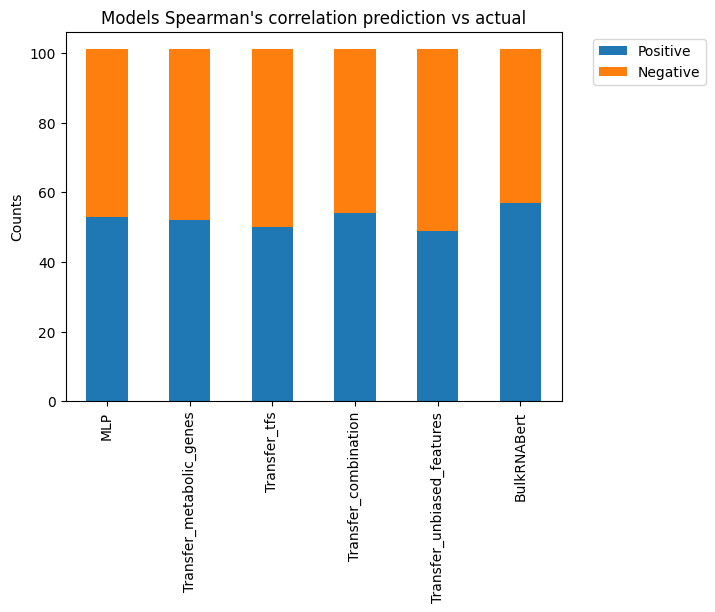

In [52]:
pos_neg.plot(kind = 'bar', stacked = True)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.title("Models Spearman's correlation prediction vs actual")
plt.ylabel('Counts')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Fudan_model_comparison_spearmans.svg', bbox_inches = 'tight')
plt.show()

#MYC case study

In [53]:
cnv = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/Fudan_TripleNegative/FUSCC_TNBC_annotation_withCNV.txt', sep = '\t')
cnv

,Transcriptomic_Sample,Tumour,HR_status,HER2_status,TNBC_status,PI3K_mutation_status,PTEN_status,PI3K_activity_status,MYC_status
0,FUSCCTNBC001,Tumor,HR-,HER2-,TNBC+,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_Gain
1,FUSCCTNBC003,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
2,FUSCCTNBC004,Tumor,HR-,HER2-,TNBC+,NaN,PTEN_Deletion,PI3K_PTEN_mut,MYC_Amplification
3,FUSCCTNBC005,Tumor,HR-,HER2-,TNBC+,PI3K_mut,PTEN_Deletion,PI3K_PTEN_mut,MYC_Amplification
4,FUSCCTNBC006,Tumor,HR-,HER2-,TNBC+,PI3K_WT,PTEN_Gain,PI3K_PTEN_WT,MYC_Gain
...,...,...,...,...,...,...,...,...,...
313,FUSCCTNBC491,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
314,FUSCCTNBC492,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
315,FUSCCTNBC493,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN
316,FUSCCTNBC494,Tumor,HR-,HER2-,TNBC+,NaN,NaN,NaN,NaN


In [54]:
cnv.MYC_status.value_counts()

,count
MYC_status,
MYC_Gain,99
MYC_Amplification,88
MYC_WT,71
MYC_Deletion,5


In [55]:
myc = cnv[['Transcriptomic_Sample', 'MYC_status']]
myc = myc.dropna()
myc

,Transcriptomic_Sample,MYC_status
0,FUSCCTNBC001,MYC_Gain
2,FUSCCTNBC004,MYC_Amplification
3,FUSCCTNBC005,MYC_Amplification
4,FUSCCTNBC006,MYC_Gain
5,FUSCCTNBC007,MYC_Amplification
...,...,...
282,FUSCCTNBC458,MYC_Amplification
284,FUSCCTNBC461,MYC_Amplification
287,FUSCCTNBC465,MYC_Gain
289,FUSCCTNBC467,MYC_Gain


In [56]:
myc.MYC_status.isna().sum()

np.int64(0)

In [57]:
myc_status = []
for i in myc.MYC_status:
  if i in ['MYC_Gain', 'MYC_Amplification']:
    myc_status.append('Gain/Amplification')
  else:
    myc_status.append('Loss/No_change')

In [58]:
myc['MYC'] = myc_status
myc = myc.set_index('Transcriptomic_Sample').drop('MYC_status', axis = 'columns')
myc

,MYC
Transcriptomic_Sample,
FUSCCTNBC001,Gain/Amplification
FUSCCTNBC004,Gain/Amplification
FUSCCTNBC005,Gain/Amplification
FUSCCTNBC006,Gain/Amplification
FUSCCTNBC007,Gain/Amplification
...,...
FUSCCTNBC458,Gain/Amplification
FUSCCTNBC461,Gain/Amplification
FUSCCTNBC465,Gain/Amplification


In [59]:
myc = myc.loc[myc.index.intersection(lcms.index)]
myc

,MYC
FUSCCTNBC001,Gain/Amplification
FUSCCTNBC004,Gain/Amplification
FUSCCTNBC005,Gain/Amplification
FUSCCTNBC006,Gain/Amplification
FUSCCTNBC007,Gain/Amplification
...,...
FUSCCTNBC441,Gain/Amplification
FUSCCTNBC443,Loss/No_change
FUSCCTNBC451,Loss/No_change
FUSCCTNBC456,Loss/No_change


In [60]:
myc.MYC.value_counts()

,count
MYC,
Gain/Amplification,139
Loss/No_change,59


In [61]:
def select_and_add_myc_status(df, myc_df):
  common_index = list(df.index.intersection(myc_df.index))
  res = pd.concat([myc_df.loc[common_index], df.loc[common_index]], axis = 'columns')
  return res

In [62]:
lcms_myc = select_and_add_myc_status(df = lcms, myc_df = myc)
mlp_pred_myc = select_and_add_myc_status(df = mlp_model_pred, myc_df = myc)
met_pred_myc = select_and_add_myc_status(df = met_model_pred, myc_df = myc)
tf_pred_myc = select_and_add_myc_status(df = tf_model_pred, myc_df = myc)
combo_pred_myc = select_and_add_myc_status(df = combo_model_pred, myc_df = myc)
var_pred_myc = select_and_add_myc_status(df = var_model_pred, myc_df = myc)
brb_pred_myc = select_and_add_myc_status(df = brb_nn_model_pred, myc_df = myc)

In [63]:
brb_pred_myc.head(2)

,MYC,HMDB0000195,HMDB0000064,HMDB0003337,HMDB0000848,HMDB0000224,HMDB0000126,HMDB0000806,HMDB0000262,HMDB0000043,...,HMDB0000767,HMDB0000089,HMDB0000211,HMDB0001565,HMDB0000532,HMDB0011737,HMDB0000139,HMDB0000755,HMDB0000267,HMDB0000168
FUSCCTNBC028,Gain/Amplification,-1.032865,3.052270,2.886129,0.724643,-0.176557,-0.954516,-0.823096,1.492034,-1.249497,...,-1.328717,2.733121,-0.480743,0.457369,3.486371,2.085117,1.50370,-2.415525,-1.926181,1.301455
FUSCCTNBC404,Loss/No_change,-1.297606,2.991796,3.082453,0.767309,-0.256012,-0.612464,-0.741196,1.594354,-1.557032,...,-1.425276,2.649091,0.274501,-0.121629,3.430522,1.757418,1.82841,-2.328069,-2.133511,1.107350


In [64]:
def get_common_metabolites(df1, df2, df3, df4, df5, df6, df7):
  common_cols = df1.columns.intersection(df2.columns)
  common_cols = common_cols.intersection(df3.columns)
  common_cols = common_cols.intersection(df4.columns)
  common_cols = common_cols.intersection(df5.columns)
  common_cols = common_cols.intersection(df6.columns)
  common_cols = common_cols.intersection(df7.columns)

  return list(common_cols)

common_metabolites = get_common_metabolites(lcms_myc, mlp_pred_myc, met_pred_myc, tf_pred_myc, combo_pred_myc, var_pred_myc, brb_pred_myc)
len(common_metabolites)

102

In [65]:
lcms_myc = lcms_myc[common_metabolites]
mlp_pred_myc = mlp_pred_myc[common_metabolites]
met_pred_myc = met_pred_myc[common_metabolites]
tf_pred_myc = tf_pred_myc[common_metabolites]
combo_pred_myc = combo_pred_myc[common_metabolites]
var_pred_myc = var_pred_myc[common_metabolites]
brb_pred_myc = brb_pred_myc[common_metabolites]

In [66]:
def get_mean_and_direction_of_change_by_group(df):
  res = df.groupby('MYC').mean()
  res = res.transpose()
  res['Higher_in_altered'] = res['Gain/Amplification'] > res['Loss/No_change']
  res.replace({True : 'yes', False : 'no'}, inplace = True)
  return res

In [67]:
lcms_myc_mean = get_mean_and_direction_of_change_by_group(lcms_myc)
mlp_myc_mean = get_mean_and_direction_of_change_by_group(mlp_pred_myc)
met_myc_mean = get_mean_and_direction_of_change_by_group(met_pred_myc)
tf_myc_mean = get_mean_and_direction_of_change_by_group(tf_pred_myc)
combo_myc_mean = get_mean_and_direction_of_change_by_group(combo_pred_myc)
var_myc_mean = get_mean_and_direction_of_change_by_group(var_pred_myc)
brb_myc_mean = get_mean_and_direction_of_change_by_group(brb_pred_myc)

In [68]:
mlp_myc_mean = mlp_myc_mean.loc[lcms_myc_mean.index][~mlp_myc_mean.index.duplicated(keep='first')]
met_myc_mean = met_myc_mean.loc[lcms_myc_mean.index][~met_myc_mean.index.duplicated(keep='first')]
tf_myc_mean = tf_myc_mean.loc[lcms_myc_mean.index][~tf_myc_mean.index.duplicated(keep='first')]
combo_myc_mean = combo_myc_mean.loc[lcms_myc_mean.index][~combo_myc_mean.index.duplicated(keep='first')]
var_myc_mean = var_myc_mean.loc[lcms_myc_mean.index][~var_myc_mean.index.duplicated(keep='first')]
brb_myc_mean = brb_myc_mean.loc[lcms_myc_mean.index][~brb_myc_mean.index.duplicated(keep='first')]

In [69]:
def get_pred_vs_actual_comparison(df_mlp, df_met, df_tf, df_combo, df_var, df_brb, df_lcms, case_study_name):
  res_dict = {}
  def get_df(df, model_name):
    res = pd.concat([df.rename(columns = {'Higher_in_altered' : 'prediction'})['prediction'], df_lcms.rename(columns = {'Higher_in_altered' : 'actual'})['actual']], axis = 'columns')
    res['comparison'] = res['prediction'] == res['actual']
    print(f'Correctly predicted metabolites from {model_name}: ' + str(list(res[res['comparison'] == True].index)))
    res_dict[model_name] = list(res[res['comparison'] == True].index)
    res_df = pd.DataFrame(res['comparison'].value_counts())
    res_df.rename(columns = {'count' : f'{model_name}'}, inplace = True)
    return res_df

  res_1 = get_df(df = df_mlp, model_name = 'MLP')
  res_2 = get_df(df = df_met, model_name = 'Transfer_metabolic_genes')
  res_3 = get_df(df = df_tf, model_name = 'Transfer_metabolic_genes_TFs')
  res_4 = get_df(df = df_combo, model_name = 'Transfer_combination')
  res_5 = get_df(df = df_var, model_name = 'Transfer_unbiased_features')
  res_6 = get_df(df = df_brb, model_name = 'BulkRNABert')

  #Final result
  res = pd.concat([res_1, res_2, res_3, res_4, res_5, res_6], axis = 'columns')

  res_transposed = res.T
  res_transposed.plot(kind='bar', stacked=True)
  locs, labels = plt.yticks()

  new_labels = [int(float(label.get_text())) for label in labels]
  plt.yticks(locs, new_labels)

  plt.title(f'Comparison of Predictions vs. Actuals ({case_study_name})')
  plt.ylabel('Count')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/{case_study_name}_pred_vs_actual.svg', bbox_inches = 'tight')
  plt.show()

  return res_dict

Correctly predicted metabolites from MLP: ['HMDB0001173', 'HMDB0000089', 'HMDB0000161', 'HMDB0000939', 'HMDB0000201', 'HMDB0001565', 'HMDB0000133', 'HMDB0000848', 'HMDB0001262', 'HMDB0000300', 'HMDB0000157', 'HMDB0011737', 'HMDB0000034', 'HMDB0000224', 'HMDB0000086', 'HMDB0000177', 'HMDB0000167', 'HMDB0000929', 'HMDB0000254', 'HMDB0000064', 'HMDB0010382', 'HMDB0003045', 'HMDB0002259', 'HMDB0000943', 'HMDB0000883', 'HMDB0000123', 'HMDB0000211', 'HMDB0000062', 'HMDB0000687', 'HMDB0000767', 'HMDB0000131', 'HMDB0000299', 'HMDB0000262', 'HMDB0000163', 'HMDB0001316', 'HMDB0000283', 'HMDB0000660', 'HMDB0000097', 'HMDB0011172', 'HMDB0000243', 'HMDB0000094', 'HMDB0000194', 'HMDB0002994', 'HMDB0000056']
Correctly predicted metabolites from Transfer_metabolic_genes: ['HMDB0000214', 'HMDB0000161', 'HMDB0000939', 'HMDB0000126', 'HMDB0000806', 'HMDB0000517', 'HMDB0001406', 'HMDB0000133', 'HMDB0000848', 'HMDB0000296', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0011737', 'HMDB000

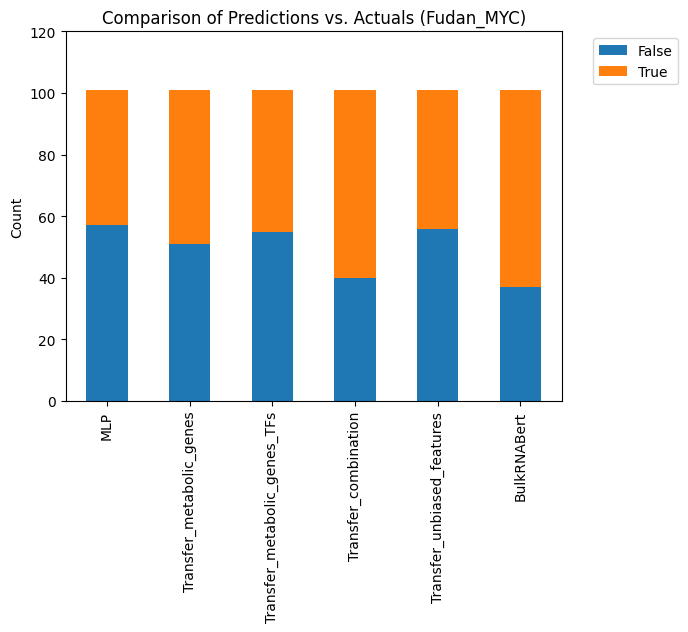

In [70]:
correct_preds_myc = get_pred_vs_actual_comparison(df_mlp = mlp_myc_mean,
                                                  df_met = met_myc_mean,
                                                  df_tf = tf_myc_mean,
                                                  df_combo = combo_myc_mean,
                                                  df_var = var_myc_mean,
                                                  df_brb = brb_myc_mean,
                                                  df_lcms = lcms_myc_mean,
                                                  case_study_name = 'Fudan_MYC')

In [71]:
from scipy.stats import ttest_ind

In [72]:
def get_statistically_significant_metabolites(df, df_mean, pval_threshold):
  grouped = df.groupby('MYC')
  mut = grouped.get_group('Gain/Amplification').drop(columns=['MYC'])
  wt = grouped.get_group('Loss/No_change').drop(columns=['MYC'])
  results = {}
  for col in mut.columns:
    t_stat, p_value = ttest_ind(mut[col], wt[col])
    results[col] = {'T-statistic': t_stat, 'P-value': p_value}
  results_df = pd.DataFrame(results).T
  results_df.index = mut.columns
  df_mean = df_mean.copy()
  df_mean.index.name = None
  res = pd.concat([df_mean, results_df], axis = 'columns')
  return res

In [73]:
myc_sig = get_statistically_significant_metabolites(df = lcms_myc, df_mean = lcms_myc_mean,  pval_threshold = 0.05)
myc_sig.head(2)
myc_sig_metabolites = list(myc_sig[myc_sig['P-value'] < 0.05].index)

Correctly predicted metabolites from MLP: ['HMDB0001173', 'HMDB0001262', 'HMDB0000177', 'HMDB0002259', 'HMDB0000211', 'HMDB0000299', 'HMDB0000056']
Correctly predicted metabolites from Transfer_metabolic_genes: ['HMDB0001262', 'HMDB0003337', 'HMDB0002259', 'HMDB0006344', 'HMDB0000594', 'HMDB0000826', 'HMDB0000532', 'HMDB0000056']
Correctly predicted metabolites from Transfer_metabolic_genes_TFs: ['HMDB0001262', 'HMDB0003337', 'HMDB0002259', 'HMDB0006344', 'HMDB0000594', 'HMDB0000826', 'HMDB0000532', 'HMDB0000056']
Correctly predicted metabolites from Transfer_combination: ['HMDB0000294', 'HMDB0000148', 'HMDB0002259', 'HMDB0006344', 'HMDB0000211', 'HMDB0000562', 'HMDB0000826', 'HMDB0000532', 'HMDB0000056']
Correctly predicted metabolites from Transfer_unbiased_features: ['HMDB0003337', 'HMDB0000684', 'HMDB0000177', 'HMDB0000071', 'HMDB0000211', 'HMDB0000594', 'HMDB0000299', 'HMDB0000766', 'HMDB0000532']
Correctly predicted metabolites from BulkRNABert: ['HMDB0001173', 'HMDB0000294', 'HM

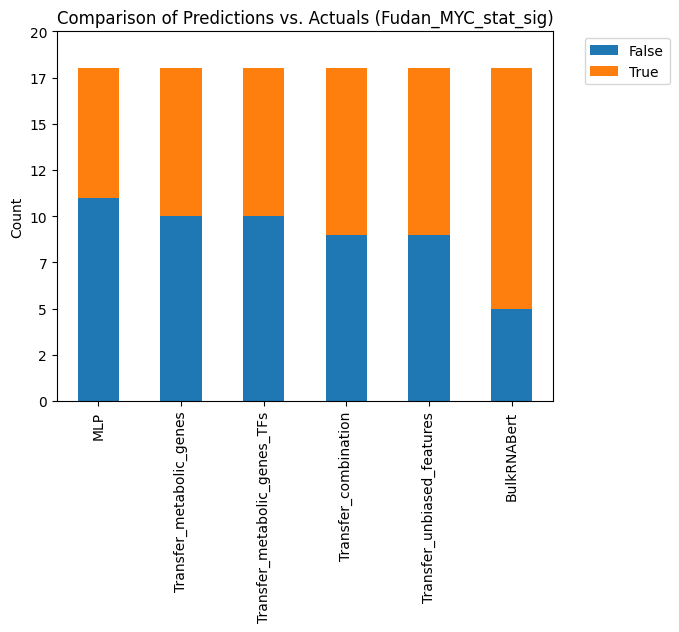

{'MLP': ['HMDB0001173',
  'HMDB0001262',
  'HMDB0000177',
  'HMDB0002259',
  'HMDB0000211',
  'HMDB0000299',
  'HMDB0000056'],
 'Transfer_metabolic_genes': ['HMDB0001262',
  'HMDB0003337',
  'HMDB0002259',
  'HMDB0006344',
  'HMDB0000594',
  'HMDB0000826',
  'HMDB0000532',
  'HMDB0000056'],
 'Transfer_metabolic_genes_TFs': ['HMDB0001262',
  'HMDB0003337',
  'HMDB0002259',
  'HMDB0006344',
  'HMDB0000594',
  'HMDB0000826',
  'HMDB0000532',
  'HMDB0000056'],
 'Transfer_combination': ['HMDB0000294',
  'HMDB0000148',
  'HMDB0002259',
  'HMDB0006344',
  'HMDB0000211',
  'HMDB0000562',
  'HMDB0000826',
  'HMDB0000532',
  'HMDB0000056'],
 'Transfer_unbiased_features': ['HMDB0003337',
  'HMDB0000684',
  'HMDB0000177',
  'HMDB0000071',
  'HMDB0000211',
  'HMDB0000594',
  'HMDB0000299',
  'HMDB0000766',
  'HMDB0000532'],
 'BulkRNABert': ['HMDB0001173',
  'HMDB0000294',
  'HMDB0000148',
  'HMDB0000177',
  'HMDB0002259',
  'HMDB0006344',
  'HMDB0000211',
  'HMDB0000299',
  'HMDB0000562',
  'HMDB00

In [74]:
#For statistically siginificant metabolites
get_pred_vs_actual_comparison(df_mlp = mlp_myc_mean.loc[myc_sig_metabolites],
                               df_met = met_myc_mean.loc[myc_sig_metabolites],
                              df_tf = tf_myc_mean.loc[myc_sig_metabolites],
                              df_combo = combo_myc_mean.loc[myc_sig_metabolites],
                              df_var = var_myc_mean.loc[myc_sig_metabolites],
                              df_brb = brb_myc_mean.loc[myc_sig_metabolites],
                              df_lcms = lcms_myc_mean.loc[myc_sig_metabolites],
                              case_study_name = 'Fudan_MYC_stat_sig')

#PI3K case study

In [75]:
pi3k = cnv[['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k

,Transcriptomic_Sample,PI3K_activity_status
0,FUSCCTNBC001,PI3K_PTEN_mut
1,FUSCCTNBC003,NaN
2,FUSCCTNBC004,PI3K_PTEN_mut
3,FUSCCTNBC005,PI3K_PTEN_mut
4,FUSCCTNBC006,PI3K_PTEN_WT
...,...,...
313,FUSCCTNBC491,NaN
314,FUSCCTNBC492,NaN
315,FUSCCTNBC493,NaN
316,FUSCCTNBC494,NaN


In [76]:
pi3k.PI3K_activity_status.value_counts()

,count
PI3K_activity_status,
PI3K_PTEN_mut,181
PI3K_PTEN_WT,92


In [77]:
pi3k = pi3k[['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k = pi3k.dropna()
pi3k = pi3k.set_index('Transcriptomic_Sample')
pi3k

,PI3K_activity_status
Transcriptomic_Sample,
FUSCCTNBC001,PI3K_PTEN_mut
FUSCCTNBC004,PI3K_PTEN_mut
FUSCCTNBC005,PI3K_PTEN_mut
FUSCCTNBC006,PI3K_PTEN_WT
FUSCCTNBC007,PI3K_PTEN_mut
...,...
FUSCCTNBC465,PI3K_PTEN_mut
FUSCCTNBC467,PI3K_PTEN_WT
FUSCCTNBC468,PI3K_PTEN_mut


In [78]:
pi3k = pi3k.loc[pi3k.index.intersection(lcms.index)]
pi3k

,PI3K_activity_status
FUSCCTNBC001,PI3K_PTEN_mut
FUSCCTNBC004,PI3K_PTEN_mut
FUSCCTNBC005,PI3K_PTEN_mut
FUSCCTNBC006,PI3K_PTEN_WT
FUSCCTNBC007,PI3K_PTEN_mut
...,...
FUSCCTNBC441,PI3K_PTEN_WT
FUSCCTNBC443,PI3K_PTEN_WT
FUSCCTNBC451,PI3K_PTEN_WT
FUSCCTNBC456,PI3K_PTEN_mut


In [79]:
pi3k.isna().sum()

,0
PI3K_activity_status,0


In [80]:
pi3k_status = []
for i in pi3k.PI3K_activity_status:
  if i  == 'PI3K_PTEN_WT':
    pi3k_status.append('WT')
  else:
    pi3k_status.append('MUT')

In [81]:
pi3k['PI3K'] = pi3k_status
pi3k = pi3k.drop('PI3K_activity_status', axis = 'columns')
pi3k

,PI3K
FUSCCTNBC001,MUT
FUSCCTNBC004,MUT
FUSCCTNBC005,MUT
FUSCCTNBC006,WT
FUSCCTNBC007,MUT
...,...
FUSCCTNBC441,WT
FUSCCTNBC443,WT
FUSCCTNBC451,WT
FUSCCTNBC456,MUT


In [82]:
pi3k.PI3K.value_counts()

,count
PI3K,
MUT,131
WT,71


In [83]:
def select_and_add_pi3k_status(df, pi3k_df):
  common_index = list(df.index.intersection(pi3k_df.index))
  res = pd.concat([pi3k_df.loc[common_index], df.loc[common_index]], axis = 'columns')
  return res

In [84]:
lcms_pi3k = select_and_add_pi3k_status(df = lcms, pi3k_df = pi3k)
mlp_pred_pi3k = select_and_add_pi3k_status(df = mlp_model_pred, pi3k_df = pi3k)
met_pred_pi3k = select_and_add_pi3k_status(df = met_model_pred, pi3k_df = pi3k)
tf_pred_pi3k = select_and_add_pi3k_status(df = tf_model_pred, pi3k_df = pi3k)
combo_pred_pi3k = select_and_add_pi3k_status(df = combo_model_pred, pi3k_df = pi3k)
var_pred_pi3k = select_and_add_pi3k_status(df = var_model_pred, pi3k_df = pi3k)
brb_pred_pi3k = select_and_add_pi3k_status(df = brb_nn_model_pred, pi3k_df = pi3k)

In [85]:
lcms_pi3k.head(2)

,PI3K,HMDB0000050,HMDB0003229,HMDB0000220,HMDB0000214,HMDB0001173,HMDB0000089,HMDB0000161,HMDB0000939,HMDB0000126,...,HMDB0000532,HMDB0000714,HMDB0011172,HMDB0000243,HMDB0000011,HMDB0000094,HMDB0000194,HMDB0002994,HMDB0000125,HMDB0000056
FUSCCTNBC028,MUT,20.572549,17.005800,19.975423,14.808763,15.701848,13.872675,14.638210,14.103288,13.501837,...,16.074309,16.803046,14.190751,20.511116,12.648358,15.762797,16.996198,16.202277,12.607330,12.567481
FUSCCTNBC404,WT,20.530790,16.470405,19.572069,13.489346,16.165457,13.688250,15.798674,15.228819,17.657535,...,15.316282,14.010178,14.867858,21.303500,13.598052,16.630665,15.221285,15.057484,13.863025,13.237807


In [86]:
common_metabolites = get_common_metabolites(lcms_pi3k, mlp_pred_pi3k, met_pred_pi3k, tf_pred_pi3k, combo_pred_pi3k, var_pred_pi3k,brb_pred_pi3k)
len(common_metabolites)

102

In [87]:
lcms_pi3k = lcms_pi3k[common_metabolites]
mlp_pred_pi3k = mlp_pred_pi3k[common_metabolites]
met_pred_pi3k = met_pred_pi3k[common_metabolites]
tf_pred_pi3k = tf_pred_pi3k[common_metabolites]
combo_pred_pi3k = combo_pred_pi3k[common_metabolites]
var_pred_pi3k = var_pred_pi3k[common_metabolites]
brb_pred_pi3k = brb_pred_pi3k[common_metabolites]

In [88]:
def get_mean_and_direction_of_change_by_group(df):
  res = df.groupby('PI3K').mean()
  res = res.transpose()
  res['Higher_in_altered'] = res['MUT'] > res['WT']
  res.replace({True : 'yes', False : 'no'}, inplace = True)
  return res

In [89]:
lcms_pi3k_mean = get_mean_and_direction_of_change_by_group(lcms_pi3k)
mlp_pi3k_mean = get_mean_and_direction_of_change_by_group(mlp_pred_pi3k)
met_pi3k_mean = get_mean_and_direction_of_change_by_group(met_pred_pi3k)
tf_pi3k_mean = get_mean_and_direction_of_change_by_group(tf_pred_pi3k)
combo_pi3k_mean = get_mean_and_direction_of_change_by_group(combo_pred_pi3k)
var_pi3k_mean = get_mean_and_direction_of_change_by_group(var_pred_pi3k)
brb_pi3k_mean = get_mean_and_direction_of_change_by_group(brb_pred_pi3k)

In [90]:
met_pi3k_mean = met_pi3k_mean.loc[lcms_pi3k_mean.index][~met_pi3k_mean.index.duplicated(keep='first')]
mlp_pi3k_mean = mlp_pi3k_mean.loc[lcms_pi3k_mean.index][~mlp_pi3k_mean.index.duplicated(keep='first')]
tf_pi3k_mean = tf_pi3k_mean.loc[lcms_pi3k_mean.index][~tf_pi3k_mean.index.duplicated(keep='first')]
combo_pi3k_mean = combo_pi3k_mean.loc[lcms_pi3k_mean.index][~combo_pi3k_mean.index.duplicated(keep='first')]
var_pi3k_mean = var_pi3k_mean.loc[lcms_pi3k_mean.index][~var_pi3k_mean.index.duplicated(keep='first')]
brb_pi3k_mean = brb_pi3k_mean.loc[lcms_pi3k_mean.index][~brb_pi3k_mean.index.duplicated(keep='first')]

Correctly predicted metabolites from MLP: ['HMDB0000050', 'HMDB0003229', 'HMDB0000220', 'HMDB0000089', 'HMDB0000126', 'HMDB0000162', 'HMDB0000294', 'HMDB0000517', 'HMDB0000673', 'HMDB0000133', 'HMDB0000159', 'HMDB0001262', 'HMDB0001348', 'HMDB0000251', 'HMDB0000300', 'HMDB0000157', 'HMDB0000034', 'HMDB0000195', 'HMDB0000148', 'HMDB0000224', 'HMDB0000684', 'HMDB0000638', 'HMDB0000158', 'HMDB0000267', 'HMDB0000827', 'HMDB0000254', 'HMDB0000043', 'HMDB0000071', 'HMDB0000625', 'HMDB0000812', 'HMDB0000168', 'HMDB0000191', 'HMDB0000943', 'HMDB0000883', 'HMDB0006344', 'HMDB0000156', 'HMDB0000210', 'HMDB0000262', 'HMDB0000163', 'HMDB0000252', 'HMDB0000139', 'HMDB0002000', 'HMDB0000695', 'HMDB0001316', 'HMDB0000283', 'HMDB0000289', 'HMDB0000660', 'HMDB0000134', 'HMDB0000766', 'HMDB0000714', 'HMDB0000011', 'HMDB0000194', 'HMDB0002994', 'HMDB0000125']
Correctly predicted metabolites from Transfer_metabolic_genes: ['HMDB0000050', 'HMDB0000161', 'HMDB0000939', 'HMDB0000806', 'HMDB0000517', 'HMDB000

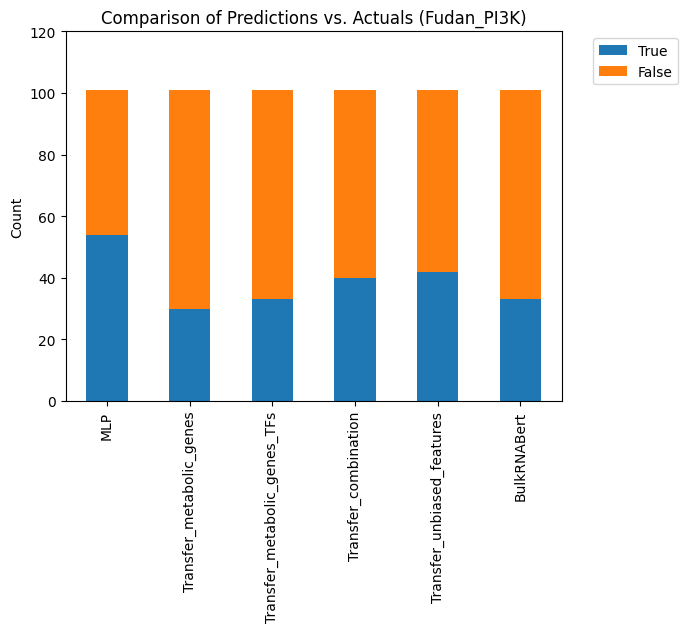

In [91]:
correct_preds_pi3k = get_pred_vs_actual_comparison(df_mlp = mlp_pi3k_mean,
                                                   df_met = met_pi3k_mean,
                                                   df_tf = tf_pi3k_mean,
                                                   df_combo = combo_pi3k_mean,
                                                   df_var = var_pi3k_mean,
                                                   df_brb = brb_myc_mean,
                                                   df_lcms = brb_pi3k_mean,
                                                   case_study_name = 'Fudan_PI3K')

In [92]:
from scipy.stats import ttest_ind

In [93]:
def get_statistically_significant_metabolites(df, df_mean, pval_threshold):
  grouped = df.groupby('PI3K')
  mut = grouped.get_group('MUT').drop(columns=['PI3K'])
  wt = grouped.get_group('WT').drop(columns=['PI3K'])
  results = {}
  for col in mut.columns:
    t_stat, p_value = ttest_ind(mut[col], wt[col])
    results[col] = {'T-statistic': t_stat, 'P-value': p_value}
  results_df = pd.DataFrame(results).T
  results_df.index = mut.columns
  df_mean = df_mean.copy()
  df_mean.index.name = None
  res = pd.concat([df_mean, results_df], axis = 'columns')
  return res

In [94]:
pi3k_sig = get_statistically_significant_metabolites(df = lcms_pi3k, df_mean = lcms_pi3k_mean,  pval_threshold = 0.05)
pi3k_sig.head(2)
pi3k_sig_metabolites = list(pi3k_sig[pi3k_sig['P-value'] < 0.05].index)

Correctly predicted metabolites from MLP: ['HMDB0000625', 'HMDB0028691']
Correctly predicted metabolites from Transfer_metabolic_genes: ['HMDB0000625', 'HMDB0028691']
Correctly predicted metabolites from Transfer_metabolic_genes_TFs: ['HMDB0000625']
Correctly predicted metabolites from Transfer_combination: ['HMDB0028691']
Correctly predicted metabolites from Transfer_unbiased_features: ['HMDB0000089', 'HMDB0000625', 'HMDB0000755', 'HMDB0028691']
Correctly predicted metabolites from BulkRNABert: ['HMDB0028691']


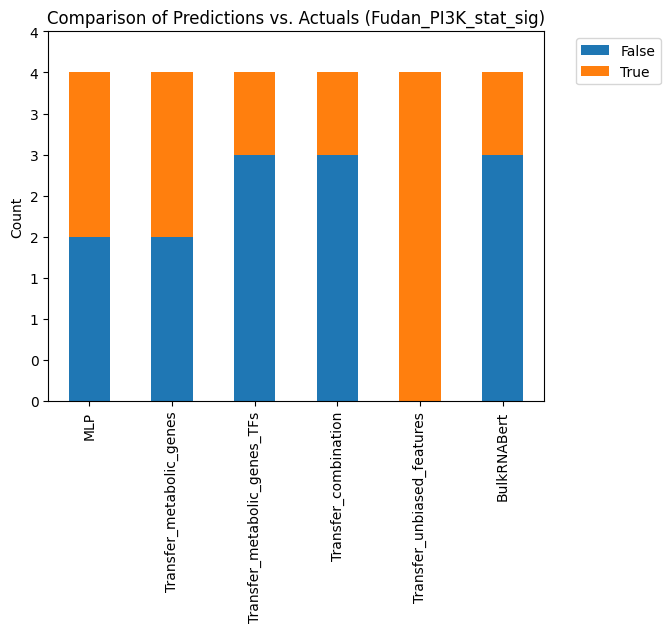

{'MLP': ['HMDB0000625', 'HMDB0028691'],
 'Transfer_metabolic_genes': ['HMDB0000625', 'HMDB0028691'],
 'Transfer_metabolic_genes_TFs': ['HMDB0000625'],
 'Transfer_combination': ['HMDB0028691'],
 'Transfer_unbiased_features': ['HMDB0000089',
  'HMDB0000625',
  'HMDB0000755',
  'HMDB0028691'],
 'BulkRNABert': ['HMDB0028691']}

In [95]:
#For statistically siginificant metabolites
get_pred_vs_actual_comparison(df_mlp = mlp_pi3k_mean.loc[pi3k_sig_metabolites],
                              df_met = met_myc_mean.loc[pi3k_sig_metabolites],
                              df_tf = tf_myc_mean.loc[pi3k_sig_metabolites],
                              df_combo = combo_myc_mean.loc[pi3k_sig_metabolites],
                              df_var = var_myc_mean.loc[pi3k_sig_metabolites],
                              df_brb = brb_myc_mean.loc[pi3k_sig_metabolites],
                              df_lcms = lcms_myc_mean.loc[pi3k_sig_metabolites],
                              case_study_name = 'Fudan_PI3K_stat_sig')

#Case study common metabolites

In [96]:
with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Fudan_MYC_PI3K_common_correct_metabolites.pkl', 'rb') as file:
    traditional_ml_metabolites_common = pickle.load(file)

len(traditional_ml_metabolites_common)

46

In [97]:
print(len(correct_preds_myc))
print(len(correct_preds_pi3k))

6
6


In [98]:
from matplotlib_venn import venn2
def get_venn_diagram(df1, df2, model_name):
  set1 = set(df1)
  set2 = set(df2)
  venn2([set1, set2], set_labels=('MYC', 'PI3K'))
  plt.title(f'Overlap Between Correct MYC And PI3K Case Metabolites\n[{model_name}]')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Fudan_MYC_PI3K_common_correct_metabolites_venn_{model_name}.svg', bbox_inches = 'tight')
  plt.show()

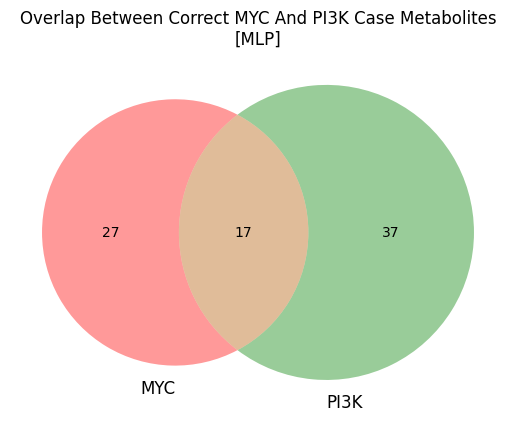

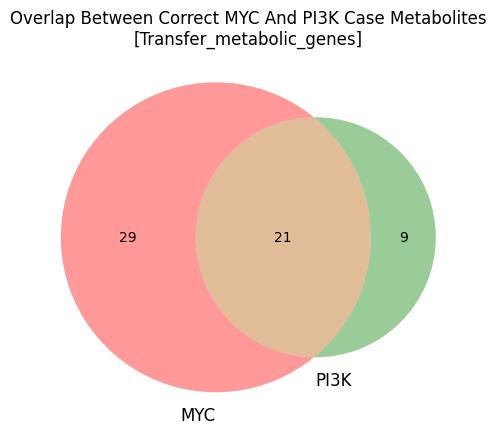

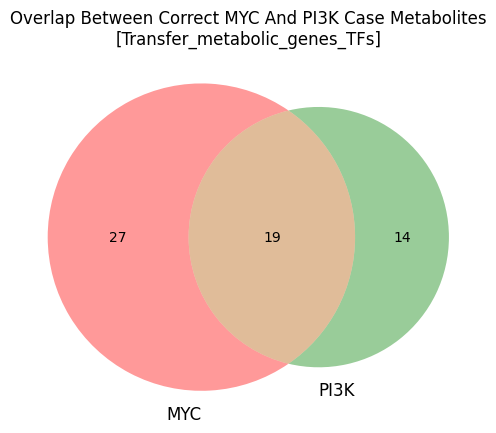

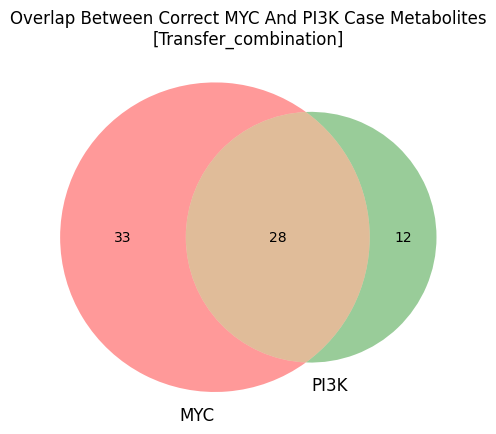

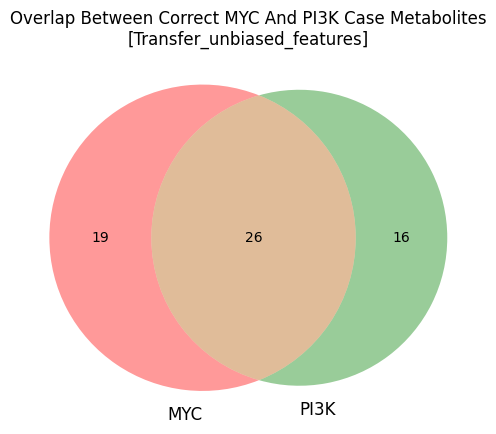

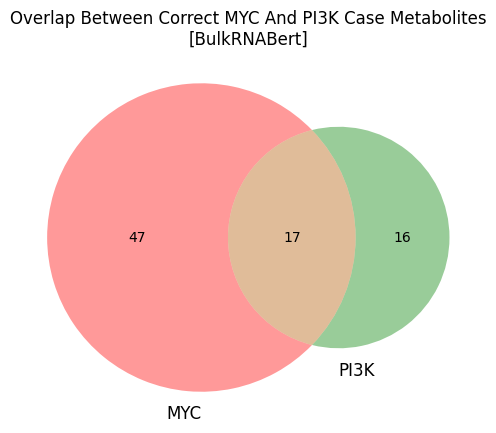

In [99]:
for i in correct_preds_myc.keys():
  myc_metabolites = correct_preds_myc[i]
  pi3k_metabolites = correct_preds_pi3k[i]
  get_venn_diagram(df1 = myc_metabolites, df2 = pi3k_metabolites, model_name = i)

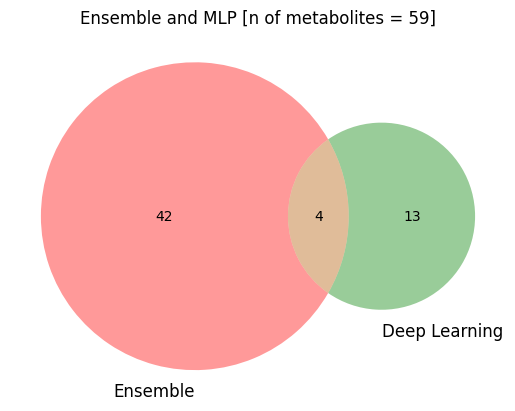

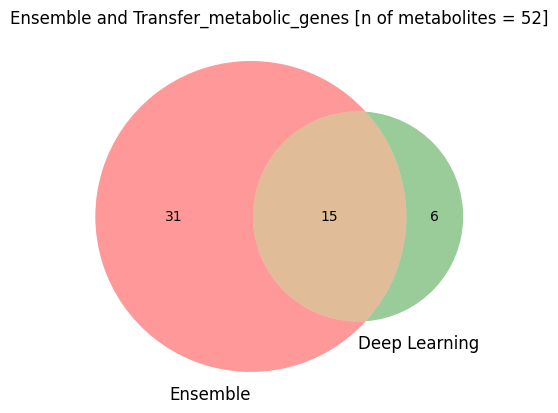

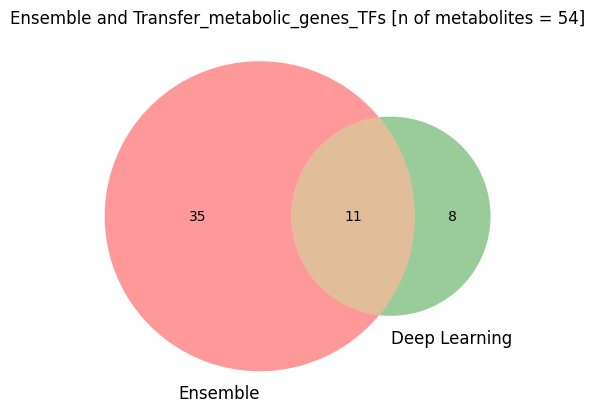

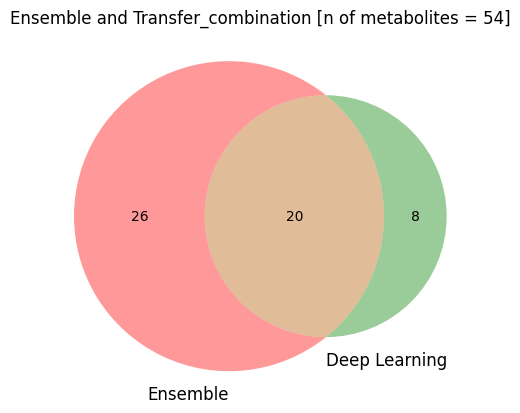

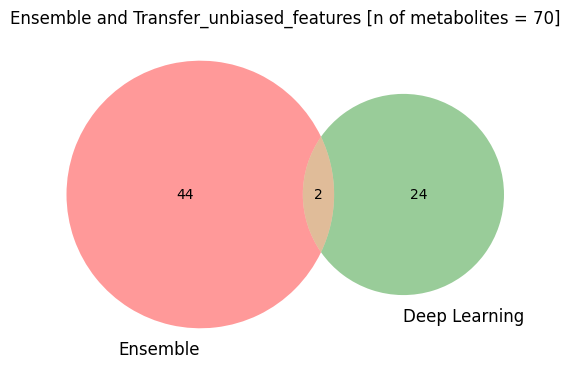

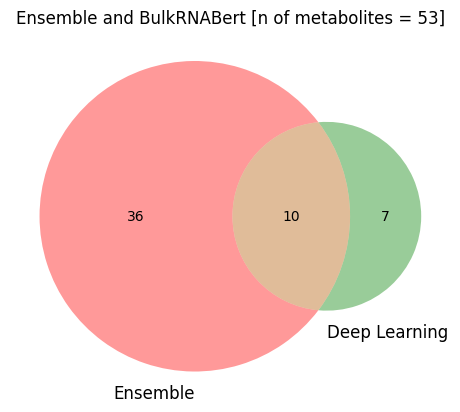

In [100]:
for i in correct_preds_myc.keys():
  dl_metabolites_common = list(
    set(correct_preds_myc[i]).intersection(
          set(correct_preds_pi3k[i])
      )
  )
  total_metabolite_n = len(list(set(dl_metabolites_common + traditional_ml_metabolites_common)))
  plt.title(f'Ensemble and {i} [n of metabolites = {total_metabolite_n}]')
  venn2([set(traditional_ml_metabolites_common), set(dl_metabolites_common)], set_labels=('Ensemble', 'Deep Learning'))
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Fudan_MYC_PI3K_common_correct_metabolites_venn_{i}_{total_metabolite_n}.svg', bbox_inches = 'tight')
  plt.show()

In [101]:
dl_metabolites_common = list(
    set(correct_preds_myc['Transfer_unbiased_features']).intersection(
        set(correct_preds_pi3k['Transfer_unbiased_features'])
    )
)

len(dl_metabolites_common)

26

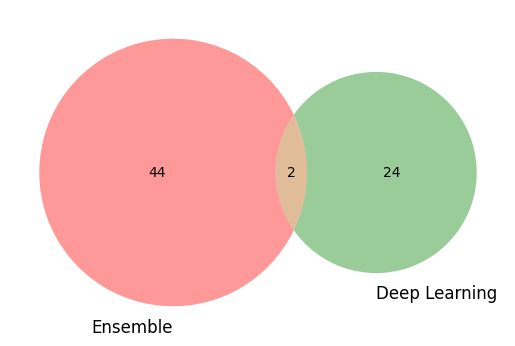

In [102]:
venn2([set(traditional_ml_metabolites_common), set(dl_metabolites_common)], set_labels=('Ensemble', 'Deep Learning'))
plt.show()

In [103]:
total_metabolites_predicted = {
    'Ensemble' : traditional_ml_metabolites_common,
    'Deep_learning_unbiased_features' : dl_metabolites_common
}
total_metabolites_predicted

{'Ensemble': ['HMDB0000870',
  'HMDB0000848',
  'HMDB0000714',
  'HMDB0000191',
  'HMDB0000251',
  'HMDB0003229',
  'HMDB0000562',
  'HMDB0000252',
  'HMDB0000696',
  'HMDB0000641',
  'HMDB0000827',
  'HMDB0000806',
  'HMDB0001316',
  'HMDB0000289',
  'HMDB0000162',
  'HMDB0000939',
  'HMDB0000262',
  'HMDB0000043',
  'HMDB0000156',
  'HMDB0000625',
  'HMDB0000532',
  'HMDB0003045',
  'HMDB0000139',
  'HMDB0000929',
  'HMDB0000826',
  'HMDB0002000',
  'HMDB0000159',
  'HMDB0011737',
  'HMDB0000086',
  'HMDB0006344',
  'HMDB0000210',
  'HMDB0000759',
  'HMDB0001348',
  'HMDB0000134',
  'HMDB0000300',
  'HMDB0000660',
  'HMDB0000071',
  'HMDB0011503',
  'HMDB0000812',
  'HMDB0001406',
  'HMDB0001173',
  'HMDB0000182',
  'HMDB0000517',
  'HMDB0000673',
  'HMDB0000695',
  'HMDB0028691'],
 'Deep_learning_unbiased_features': ['HMDB0000195',
  'HMDB0000064',
  'HMDB0000097',
  'HMDB0000177',
  'HMDB0000167',
  'HMDB0000224',
  'HMDB0000126',
  'HMDB0000254',
  'HMDB0000767',
  'HMDB0028691',


In [104]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/total_metabolites_predicted.pkl', 'wb') as file:
    pickle.dump(total_metabolites_predicted, file)

#Comparison of traditional ML vs deep learning and combination

In [105]:
comp = {
    'Ensemble' : [41, 61],
    'Deep_learning_unbiased_features' : [26, 76],
    'Combination' : [70, 32]
}
comp = pd.DataFrame(comp, index = ['True', 'False'])
comp

,Ensemble,Deep_learning_unbiased_features,Combination
True,41,26,70
False,61,76,32


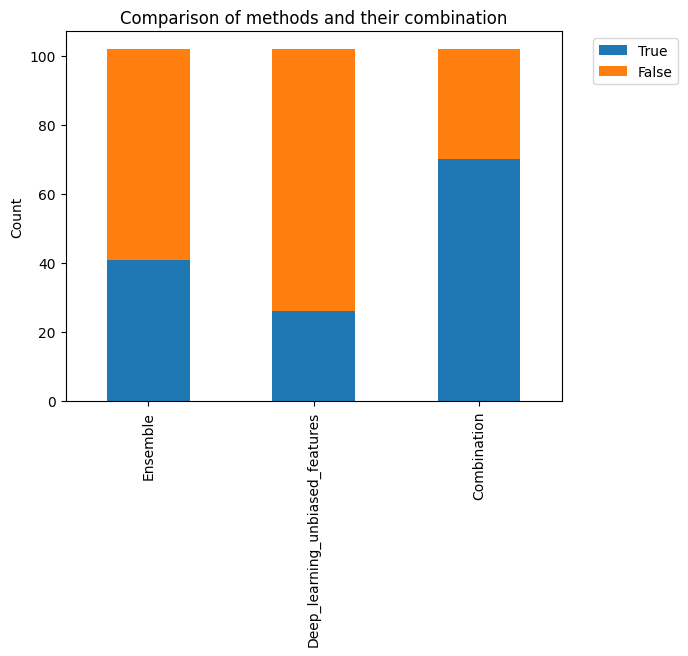

In [106]:
comp.T.plot(kind='bar', stacked=True)
plt.title(f'Comparison of methods and their combination')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Traditionl_ML_DL_combination_comparison.svg', bbox_inches = 'tight')
plt.show()

#Pathway overrepresentation for input features

In [107]:
#Pathway overrepresentation for genes (Reactome)
gene_list = []
for i in var_model_input_features:
  gene_list.append(i)

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/var_genes.txt', 'w') as file:
  for i in gene_list:
    file.write(i + '\n')

len(gene_list)

3030

In [108]:
gene_names = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/SUM149_BRCA1_DESeq2/ensembl_id_gene_name.csv')
gene_names = gene_names.rename(columns = {'gene_name' : 'Symbol'})
gene_names

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000210082,MT-RNR2
...,...,...
58730,ENSG00000276351,RF01973
58731,ENSG00000275661,RF01974
58732,ENSG00000277856,AC233755.2
58733,ENSG00000275063,AC233755.1


In [109]:
gene_names = gene_names[gene_names['gene_id'].isin(gene_list)]
gene_names

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000210082,MT-RNR2
...,...,...
58433,ENSG00000277739,RNA5-8SN2
58437,ENSG00000278775,RF01518
58642,ENSG00000205927,OLIG2
58674,ENSG00000160180,TFF3


In [110]:
gene_names_list = gene_names.Symbol.to_list()
len(gene_names_list)

3029

In [111]:
!pip install gseapy --quiet
import gseapy as gp

In [112]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMa

In [113]:
def run_pathway_analysis(gene_list, library_name):
  enr = gp.enrichr(gene_list=gene_list,
                   gene_sets=[library_name],
                   organism='Human',
                   no_plot=True)
  results = enr.results
  results = results.sort_values(by = 'Overlap', ascending = False)
  results['log2_odds_ratio'] = results['Odds Ratio'].apply(lambda x: np.log2(x + 1))
  results['score'] = results['Overlap']
  results['score'] = results['score'].apply(lambda x: eval(x))

  return results

In [114]:
pathways_input_genes = run_pathway_analysis(gene_list = gene_names_list, library_name = 'KEGG_2021_Human')
pathways_input_genes.head(3)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,log2_odds_ratio,score
2,KEGG_2021_Human,Parkinson disease,98/249,8.009380e-21,8.516641e-19,0,0,3.727412,172.481041,CALML5;UBE2L6;PARK7;TXN2;PSMD8;TUBB6;PSMD4;PSM...,2.241051,0.393574
22,KEGG_2021_Human,PI3K-Akt signaling pathway,96/354,3.457267e-09,4.795079e-08,0,0,2.121984,41.342162,ITGB1;YWHAE;CDKN1A;CDKN1B;HSP90AB1;ITGB5;ITGB4...,1.642463,0.271186
14,KEGG_2021_Human,Huntington disease,92/306,2.010690e-11,4.276068e-10,0,0,2.454788,60.461333,COX7B;COX4I1;CLTC;COX4I2;CLTB;CLTA;COX7C;PSMD8...,1.788597,0.300654


/tmp/ipython-input-2849730095.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


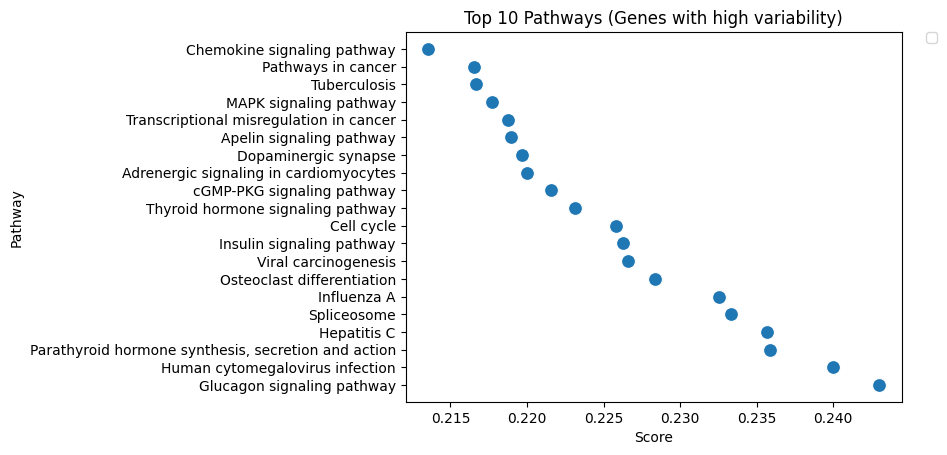

In [115]:
def plot_pathway_results(enr_results, top_no, name):

  plot_data = enr_results[enr_results['Adjusted P-value'] <= 0.05].sort_values(by = 'score', ascending = True)
  sns.scatterplot(data = plot_data.head(top_no), x = 'score', y = 'Term', s = 100)
  plt.title(f'Top 10 Pathways ({name})')
  plt.xlabel('Score')
  plt.ylabel('Pathway')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Gene_pathways_enr_{name}.svg', bbox_inches = 'tight')
  plt.show()

plot_pathway_results(enr_results = pathways_input_genes, top_no = 20, name = 'Genes with high variability')

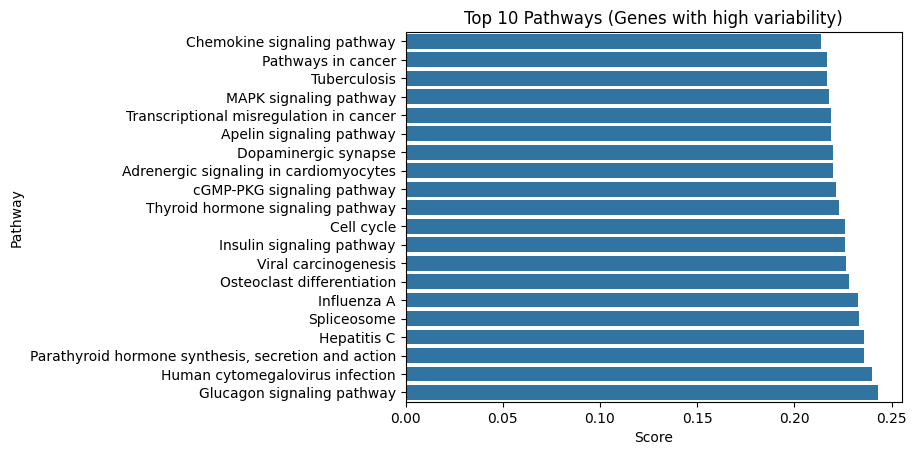

In [116]:
def barplot_pathway_results(enr_results, top_no, name):

  plot_data = enr_results[enr_results['Adjusted P-value'] <= 0.05].sort_values(by = 'score', ascending = True)
  sns.barplot(data = plot_data.head(top_no), x = 'score', y = 'Term')
  plt.title(f'Top 10 Pathways ({name})')
  plt.xlabel('Score')
  plt.ylabel('Pathway')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Gene_pathways_enr_{name}_barplot.svg', bbox_inches = 'tight')
  plt.show()

barplot_pathway_results(enr_results = pathways_input_genes, top_no = 20, name = 'Genes with high variability')

In [117]:
met_genes = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/FBA_metabolic_atlas_models/human_gem_associated_genes.csv')
met_genes

,gene_id,Symbol
0,ENSG00000198712,MT-CO2
1,ENSG00000198804,MT-CO1
2,ENSG00000198938,MT-CO3
3,ENSG00000198899,MT-ATP6
4,ENSG00000198886,MT-ND4
...,...,...
2879,ENSG00000167751,KLK2
2880,ENSG00000129873,CDY2B
2881,ENSG00000182415,CDY2A
2882,ENSG00000172352,CDY1B


In [118]:
pathways_input_met_genes = run_pathway_analysis(gene_list = met_genes.Symbol.to_list(), library_name = 'KEGG_2021_Human')
pathways_input_met_genes.head(3)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,log2_odds_ratio,score
3,KEGG_2021_Human,Glycerophospholipid metabolism,91/98,4.106472e-68,3.213314e-66,0,0,79.633727,12356.225699,DGKG;ACHE;DGKE;DGKD;LPGAT1;DGKB;DGKA;LPCAT1;TA...,6.333312,0.928571
221,KEGG_2021_Human,B cell receptor signaling pathway,9/81,8.438833e-01,9.999961e-01,0,0,0.741043,0.125786,PIK3CA;INPP5D;INPPL1;PLCG2;PIK3CD;PIK3R3;PIK3R...,0.799952,0.111111
218,KEGG_2021_Human,RNA degradation,9/79,8.222104e-01,9.999961e-01,0,0,0.762306,0.149228,CNOT4;PFKL;MTREX;ENO1;ENO2;TENT4A;ENO3;PFKM;PFKP,0.817464,0.113924


/tmp/ipython-input-2849730095.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


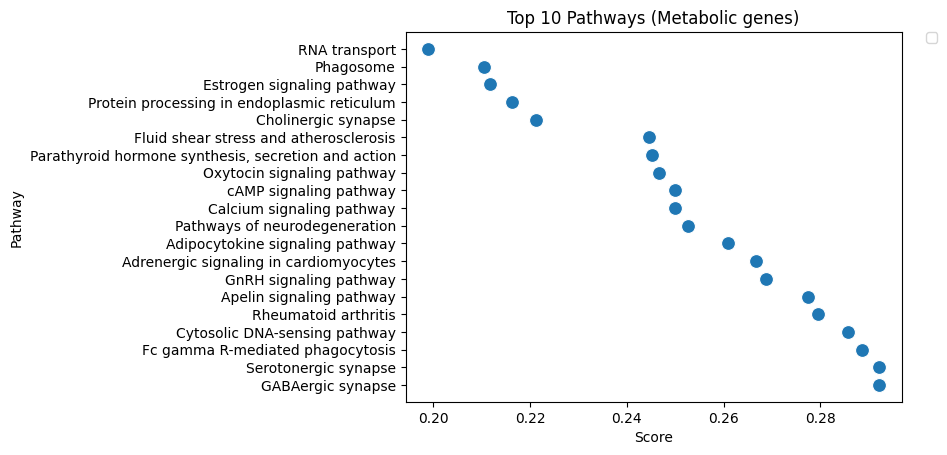

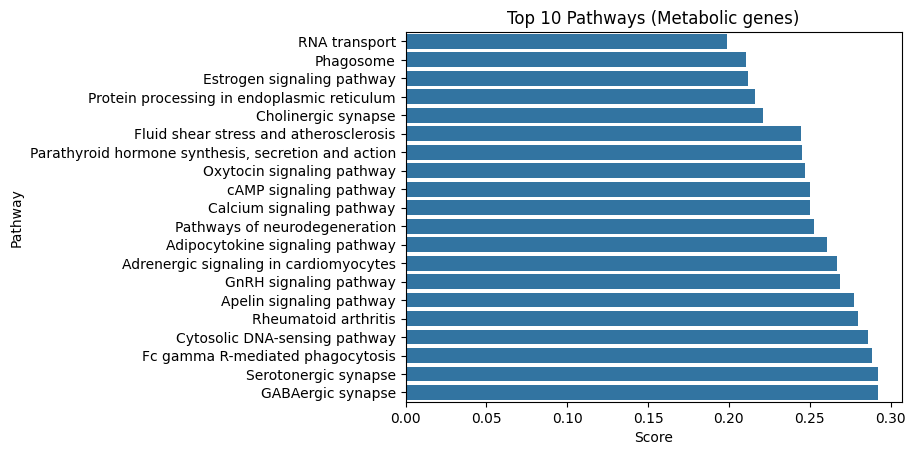

In [119]:
plot_pathway_results(enr_results = pathways_input_met_genes, top_no = 20, name = 'Metabolic genes')
barplot_pathway_results(enr_results = pathways_input_met_genes, top_no = 20, name = 'Metabolic genes')

#Pathway overrepresentation for output features

In [120]:
total_metabolites_predicted

{'Ensemble': ['HMDB0000870',
  'HMDB0000848',
  'HMDB0000714',
  'HMDB0000191',
  'HMDB0000251',
  'HMDB0003229',
  'HMDB0000562',
  'HMDB0000252',
  'HMDB0000696',
  'HMDB0000641',
  'HMDB0000827',
  'HMDB0000806',
  'HMDB0001316',
  'HMDB0000289',
  'HMDB0000162',
  'HMDB0000939',
  'HMDB0000262',
  'HMDB0000043',
  'HMDB0000156',
  'HMDB0000625',
  'HMDB0000532',
  'HMDB0003045',
  'HMDB0000139',
  'HMDB0000929',
  'HMDB0000826',
  'HMDB0002000',
  'HMDB0000159',
  'HMDB0011737',
  'HMDB0000086',
  'HMDB0006344',
  'HMDB0000210',
  'HMDB0000759',
  'HMDB0001348',
  'HMDB0000134',
  'HMDB0000300',
  'HMDB0000660',
  'HMDB0000071',
  'HMDB0011503',
  'HMDB0000812',
  'HMDB0001406',
  'HMDB0001173',
  'HMDB0000182',
  'HMDB0000517',
  'HMDB0000673',
  'HMDB0000695',
  'HMDB0028691'],
 'Deep_learning_unbiased_features': ['HMDB0000195',
  'HMDB0000064',
  'HMDB0000097',
  'HMDB0000177',
  'HMDB0000167',
  'HMDB0000224',
  'HMDB0000126',
  'HMDB0000254',
  'HMDB0000767',
  'HMDB0028691',


In [121]:
#Pathway enrichment for metabolites (MetaboAnalyst)
dl_features = []
for i in total_metabolites_predicted['Deep_learning_unbiased_features']:
  dl_features.append(i)

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/dl_output_correct_metabolitess.txt', 'w') as file:
  for i in dl_features:
    file.write(i + '\n')

In [122]:
ml_features = []
for i in total_metabolites_predicted['Ensemble']:
  ml_features.append(i)

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/ml_output_correct_metabolitess.txt', 'w') as file:
  for i in ml_features:
    file.write(i + '\n')

In [123]:
ml_metab_pathways = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/ML_metaboanalyst_pathway_results.csv', index_col = 0).sort_values(by = 'Impact', ascending = False)
ml_metab_pathways

,Total,Expected,Hits,Raw p,-log10(p),Holm adjust,FDR,Impact
Linoleic acid metabolism,5,0.103640,1,0.099555,1.00190,1.000000,0.530960,1.00000
"Phenylalanine, tyrosine and tryptophan biosynthesis",4,0.082915,1,0.080445,1.09450,1.000000,0.459690,0.50000
Taurine and hypotaurine metabolism,8,0.165830,1,0.154600,0.81079,1.000000,0.580870,0.42857
"Alanine, aspartate and glutamate metabolism",28,0.580400,4,0.002208,2.65600,0.174450,0.088330,0.42628
Phenylalanine metabolism,8,0.165830,1,0.154600,0.81079,1.000000,0.580870,0.35714
Nicotinate and nicotinamide metabolism,15,0.310930,2,0.036975,1.43210,1.000000,0.357320,0.19430
Histidine metabolism,16,0.331660,2,0.041717,1.37970,1.000000,0.357320,0.18852
One carbon pool by folate,26,0.538940,3,0.015252,1.81670,1.000000,0.244020,0.18365
Pentose phosphate pathway,23,0.476760,3,0.010838,1.96510,0.834510,0.216760,0.15659
Cysteine and methionine metabolism,33,0.684050,3,0.029004,1.53750,1.000000,0.331470,0.15194


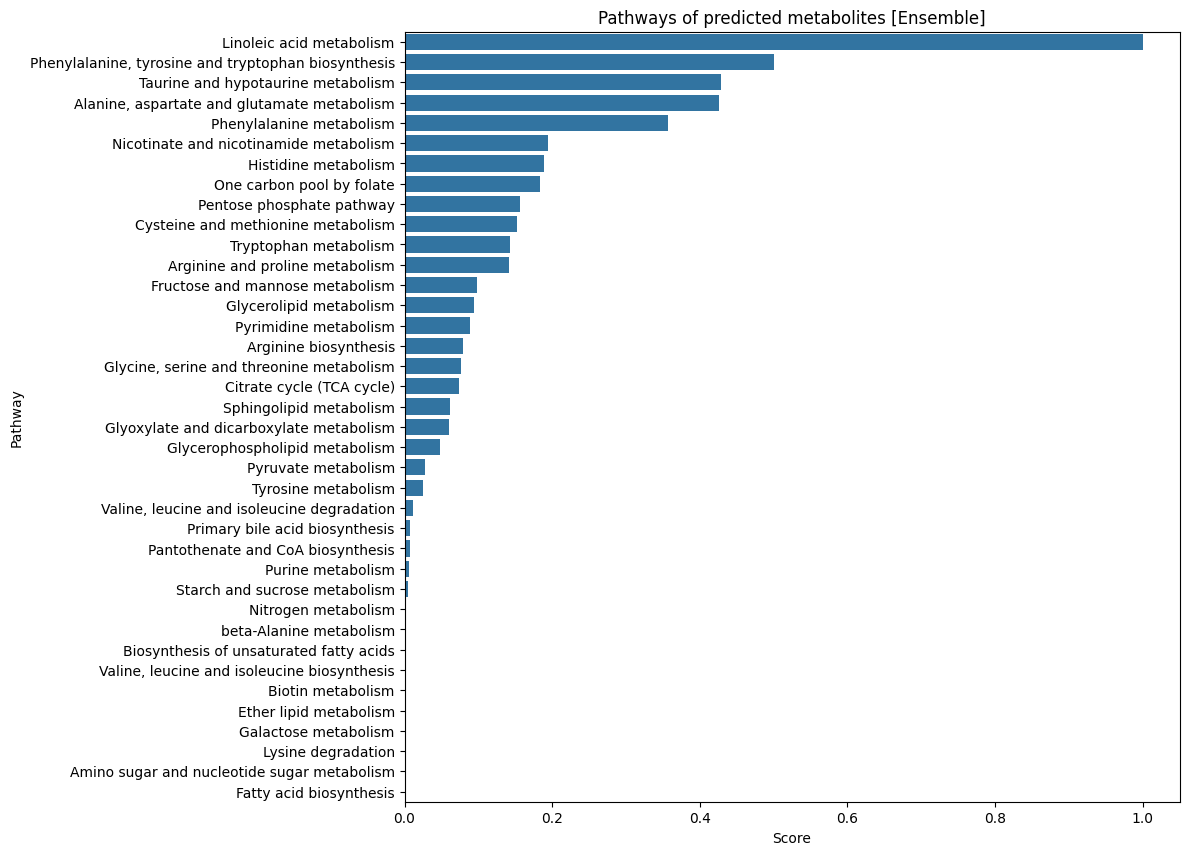

In [124]:
plt.figure(figsize = (10, 10))
sns.barplot(data = ml_metab_pathways, x = 'Impact', y = ml_metab_pathways.index)
plt.title('Pathways of predicted metabolites [Ensemble]')
plt.xlabel('Score')
plt.ylabel('Pathway')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Ensemble_metabolite_pathways.svg', bbox_inches = 'tight')
plt.show()

In [125]:
dl_metab_pathways = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/DL_metaboanalyst_pathway_results.csv', index_col = 0).sort_values(by = 'Impact', ascending = False)
dl_metab_pathways

,Total,Expected,Hits,Raw p,-log10(p),Holm adjust,FDR,Impact
Linoleic acid metabolism,5,0.050251,1,0.049312,1.30700,1.00000,0.58897,1.00000
"Alanine, aspartate and glutamate metabolism",28,0.281410,2,0.030750,1.51220,1.00000,0.58897,0.19712
Inositol phosphate metabolism,30,0.301510,1,0.263500,0.57922,1.00000,1.00000,0.12939
Arginine biosynthesis,14,0.140700,1,0.132380,0.87818,1.00000,0.94762,0.12234
Fructose and mannose metabolism,20,0.201010,1,0.183920,0.73537,1.00000,0.98091,0.09765
Tryptophan metabolism,41,0.412060,1,0.342600,0.46521,1.00000,1.00000,0.09417
Pyrimidine metabolism,39,0.391960,2,0.056534,1.24770,1.00000,0.58897,0.07618
Glycerophospholipid metabolism,36,0.361810,3,0.004861,2.31330,0.38886,0.38886,0.05247
Arginine and proline metabolism,36,0.361810,2,0.048913,1.31060,1.00000,0.58897,0.02442
Glutathione metabolism,28,0.281410,1,0.248190,0.60522,1.00000,1.00000,0.01966


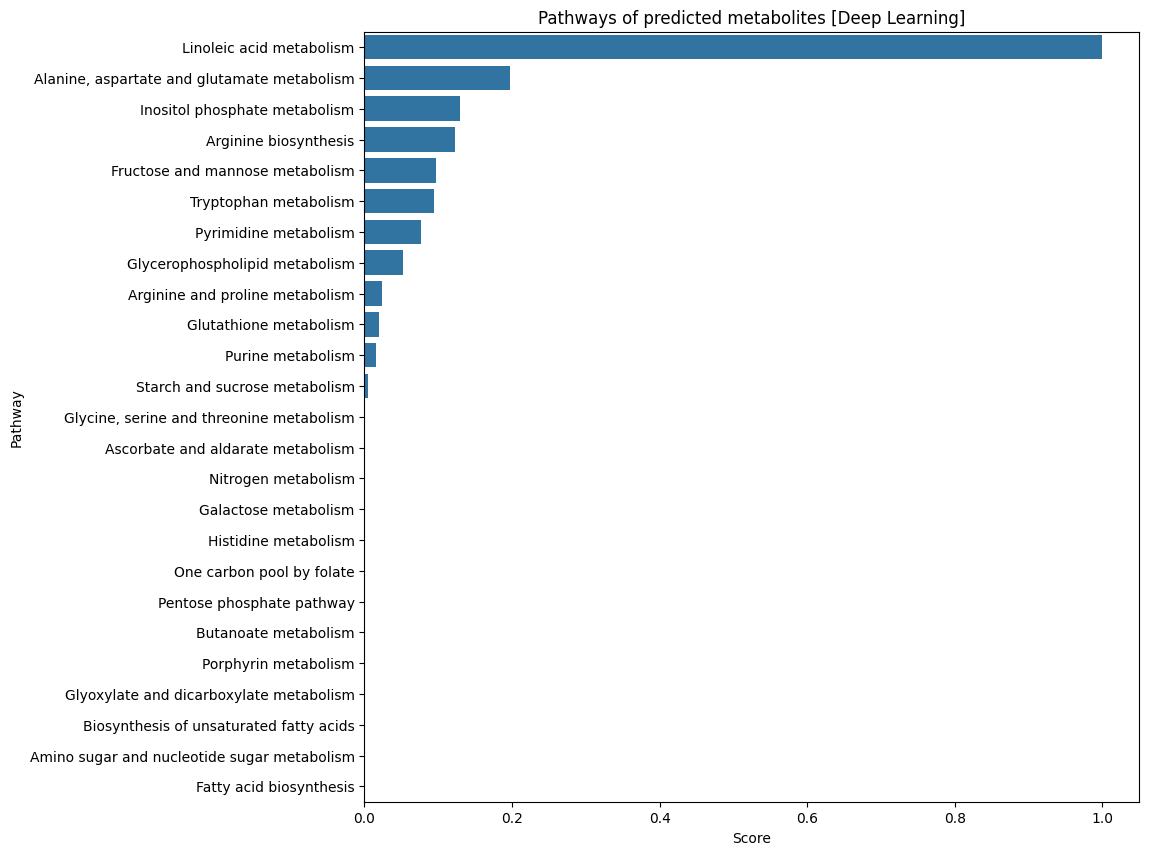

In [126]:
plt.figure(figsize = (10, 10))
sns.barplot(data = dl_metab_pathways, x = 'Impact', y = dl_metab_pathways.index)
plt.title('Pathways of predicted metabolites [Deep Learning]')
plt.xlabel('Score')
plt.ylabel('Pathway')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Deep_learning_metabolite_pathways.svg', bbox_inches = 'tight')
plt.show()

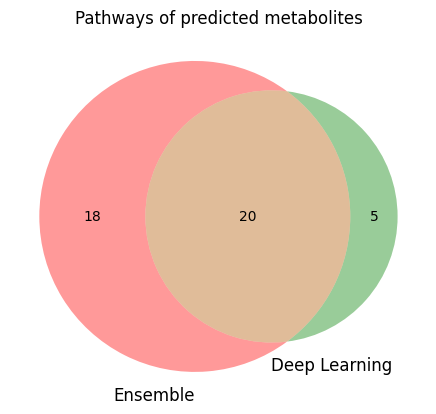

In [127]:
plt.title('Pathways of predicted metabolites')
venn2([set(ml_metab_pathways.index), set(dl_metab_pathways.index)], set_labels = ('Ensemble', 'Deep Learning'))
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/Ensemble_DL_metabolite_common_pathways_venn.svg', bbox_inches = 'tight')
plt.show()